# 04 - Çalışma Zamanı Tahmin Modelleri

## Amaç ve Kapsam

Bu kapsamlı not defteri, veri mühendisliği aşamasında (Notebook 03) oluşturulan köklü iş yükü boyutlarını kullanarak, hem makine öğrenmesi hem de sinir ağı motorlarının hibrit eğitimini ve titiz optimizasyonunu gerçekleştirir. Sadece basit istatistiksel uygulamaların ötesine geçerek, kategorik veri enjeksiyonunun (One-Hot kodlamaya karşı Doğal Kategorik işleme) mantıksal ve donanımsal altyapı maliyetlerini hem derin öğrenme hem de ağaç tabanlı algoritmalar üzerinden ampirik olarak ölçer.

Temel analiz, birbirine sıkı sıkıya bağlı 6 aşamalı (sıralı) bir alan üzerinden kusursuzca inşa edilmiştir:

1.  **Deney A:** Klasik Makine Öğrenmesi Modelleri — *Yalnızca Sayısal Özellikler (Numeric-Only ML)*
2.  **Deney B:** Klasik Makine Öğrenmesi Modelleri — *Kategorik Kodlamanın Katkısı (One-Hot ML)*
3.  **Deney C:** Statik Derin Öğrenme Modelleri — *Yalnızca Sayısal Özellikler (Numeric-Only DL)*
4.  **Deney D:** Statik Derin Öğrenme Modelleri — *Kategorik Kodlamanın Katkısı (One-Hot DL)*
5.  **Deney E:** Zamansal Derin Öğrenme Modelleri — *Yalnızca Sayısal Özellikler (Numeric-Only DL Sequence)*
6.  **Deney F:** Zamansal Derin Öğrenme Modelleri — *Kategorik Kodlamanın Katkısı (One-Hot DL Sequence)*

Nihai amaç, Pipeline aşaması 05'te inşa edilen devasa zamanlama algoritmaları için otonom bir beyin olarak çalışacak "En İyi" (The Best) tahminsel mimariyi kesin olarak tanımlamak ve izole etmektir.

## Problem Tanımı ve Tahmin Hedefi

Bu notebook’ta amaç, Alibaba PAI GPU iş yükü için **iş çalışma süresini (job runtime)** tahmin etmektir. Tahmin edilen hedef değişken, her bir işin gerçek çalışma süresi olan `job_runtime` (saniye cinsinden) değeridir.

Girdi olarak, işlerin kaynak talepleri (**GPU**, **CPU**, **instance sayısı**) ve zamansal özellikleri kullanılmaktadır. Bu problem, sürekli bir hedef değişkenin tahmin edildiği **regresyon problemi** olarak ele alınmaktadır.

## Özellik Oluşturma ve Temsili

Model eğitimi için kullanılan veri ve özellikler, prepare_features_for_model fonksiyonu aracılığıyla hazırlanmıştır.
Bu fonksiyon aşağıdaki adımları gerçekleştirmektedir:

- Ön işlenmiş iş tablosunu yükler

- Sayısal ve kategorik özellikleri ayırır

- Hedef değişken olarak gerçek iş süresini (job_runtime) belirler

- Veriyi %80 eğitim – %20 test olacak şekilde böler

Bu sayede tüm modeller aynı eğitim ve test bölünmesi üzerinde adil bir biçimde karşılaştırılabilmektedir.

## Hiperparametre Ayarlama Stratejisi

Bu çalışmada tüm modeller için aynı, üç adımlı hiperparametre ayar protokolü izlenmiştir:

- **(1) RandomizedSearchCV:** Geniş arama uzayı üzerinde sınırlı sayıda deneme ile iyi bir bölge hızlıca keşfedilir.  
- **(2) Narrow GridSearchCV:** RandomizedSearch ile bulunan en iyi ayarların çevresinde, daraltılmış bir ızgara ile ince ayar yapılır.  
- **(3) Final Refit:** Seçilen en iyi hiperparametrelerle model yalnızca eğitim verisi üzerinde yeniden eğitilir; bu aşamada **XGBoost** ve **LightGBM** için eğitim verisi içinden ayrılan bir doğrulama kümesi kullanılarak **early stopping** uygulanır (Random Forest için uygulanmaz).

(1) ve (2) adımlarında amaç **Cross Validation MAE** değerini iyileştirmektir; **test kümesi tuning sırasında kullanılmaz** ve yalnızca en sonda nihai değerlendirme için ayrılmıştır.


In [1]:
# ── 0. Environment & Path Setup ──────────────────────────────────────────────
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"[Setup] Project root : {PROJECT_ROOT}")

[Setup] Project root : /Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling


In [2]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
# stdlib / third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
from IPython.display import display
# Project
import src.tuning
import importlib
importlib.reload(src.tuning)
import src.feature_engineering
importlib.reload(src.feature_engineering)
from src.tuning import load_dl_config
from src.feature_engineering import prepare_features_for_model
from src.tuning import (
    run_randomsearch_rf, 
    run_randomsearch_xgb, 
    run_randomsearch_lgbm,
    run_gridsearch_rf, 
    run_gridsearch_xgb, 
    run_gridsearch_lgbm,
    finalize_ml_model,
    prepare_dl_datasets,
    run_randomsearch_cnn,   
    run_randomsearch_lstm,   
    run_randomsearch_hybrid,
    run_gridsearch_cnn,     
    run_gridsearch_lstm,     
    run_gridsearch_hybrid,
    finalize_dl_model, 
    make_narrow_grid,
    save_checkpoint,
    load_checkpoint,
    load_all_checkpoints,
)
# Unified visualisation theme — applied globally for the whole notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.family": "DejaVu Sans",
})
MODEL_DIR = PROJECT_ROOT / "results" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print("[Setup] All imports OK.")
print(f"[Setup] Model output : {MODEL_DIR}")
print(f"[Setup] PyTorch      : {torch.__version__}")

[Setup] All imports OK.
[Setup] Model output : /Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling/results/models
[Setup] PyTorch      : 2.11.0


In [3]:
# ── 2. Load Hyperparameter Configuration ─────────────────────────────────────
dl_config = load_dl_config()
print("[Setup] DL config loaded.")

[Setup] DL config loaded.


## Deney A: Klasik Makine Öğrenmesi Modelleri (Yalnızca Sayısal Özellikler)

Bu bölüm, klasik makine öğrenmesi algoritmalarını yalnızca sayısal topoloji parametrelerini kullanarak eğitir ve sonradan eklenecek kategorik unsurların tahminsel etkisini doğru bir şekilde ölçebilmek için temel bir referans çizgisi (baseline) oluşturur.

In [4]:
# ── 3. Experiment A: Data Preparation (Numeric-Only) ─────────────────────────
print("[Exp A] Loading numeric-only feature set...")
(job_df,
 X_train, X_test,
 y_train, y_test,
 num_cols, cat_cols) = prepare_features_for_model(
    dataset="main",
    time_unit="s",
    test_size=0.20,
    random_state=42,
    feature_mode="numeric_only",
)
print(f"[Exp A] X_train : {X_train.shape}  |  X_test : {X_test.shape}")

[Exp A] Loading numeric-only feature set...
[Exp A] X_train : (65747, 9)  |  X_test : (16437, 9)


Model girdileri, ham veriden türetilen **sayısal** ve **kategorik** özelliklerden oluşmaktadır.

Kullanılan **sayısal özellikler**:
- `gpu_demand`: Talep edilen GPU sayısı  
- `num_cpu`: Talep edilen CPU sayısı  
- `num_inst`: Kullanılan instance sayısı  
- `arrival_sec`: İz başlangıcına göre göreli geliş zamanı (saniye)  
- `hour_of_day`: Günün saati  
- `day_of_week`: Haftanın günü (0 = Pazartesi, göreli zaman)  
- `cluster_load_cpu`: İşin sisteme ulaştığı andaki arka plan CPU yükü  
- `cluster_load_gpu`: İşin sisteme ulaştığı andaki arka plan GPU yükü  
- `active_job_count`: İşin sisteme ulaştığı anda kümedeki aktif iş sayısı  

Kullanılan **kategorik özellikler**:
- `user`: İş sahibi kullanıcı  
- `gpu_type`: Kullanılan GPU tipi  

Bu çalışma 6 aşamalı (senaryolu) bir özellik temsili üzerine kurulmuştur:

- **(A) Makine Öğrenme Temel Senaryosu (Numeric-Only Baseline):**  
  Modellerin aynı özellik uzayında çalışmasını sağlamak için yalnızca yukarıdaki **sayısal özellikler** kullanılmıştır. Bu sayede **Random Forest**, **XGBoost** ve **LightGBM** modelleri doğrudan ve adil biçimde karşılaştırılabilmiştir.

- **(B) Makine Öğrenme ile Kategorik Özellik Entegrasyonu (One-Hot Encoding):**  
  Kategorik bilginin katkısı ayrıca incelenmiştir. Bu senaryoda `user` ve `gpu_type` değişkenleri:
  - **Random Forest / XGBoost / LGBM** için **one-hot encoding** ile sayısal uzaya taşınmıştır.
  - **LightGBM** için **native categorical** biçimde korunmuştur.

- **(C) Derin Öğrenme Temel Senaryosu (Numeric-Only Baseline):**  
  Sinir ağı mimarilerinin kategorik bilgi olmadan öğrenme kapasitesini değerlendirmek amacıyla derin öğrenme modelleri yalnızca **sayısal özellikler** kullanılarak eğitilmiştir.  
  Bu deney kapsamında aşağıdaki mimariler kullanılmıştır:
  - **1D-CNN**
  - **LSTM**
  - **CNN–LSTM Hybrid**

  Bu kurulum, makine öğrenmesi modellerinin yer aldığı **Deney A** ile aynı özellik uzayını kullanarak doğrudan yapısal bir karşılaştırma yapılmasına olanak sağlar.

- **(D) Derin Öğrenme ile Kategorik Özellik Entegrasyonu (One-Hot Encoding):**  
  Sinir ağlarının yüksek boyutlu veri temsillerinden karmaşık örüntüler öğrenme kapasitesini değerlendirmek amacıyla `user` ve `gpu_type` değişkenleri **one-hot encoding** yöntemiyle modele dahil edilmiştir.  
  Bu deney kapsamında aşağıdaki derin öğrenme mimarileri kullanılmıştır:

  - **1D-CNN**  
  - **LSTM**  
  - **CNN-LSTM Hybrid**

  Bu yapı, ağın hem **sayısal metriklerden** hem de **seyrek kategorik vektörlerden** eş zamanlı olarak ortak temsiller öğrenmesini ve özellikler arasındaki karmaşık ilişkileri yakalamasını hedefler.


- **(E) Zamansal Kayan Pencereli Derin Öğrenme Senaryosu (Numeric-Only Sequence):**  
  Sinir ağı mimarilerinin kısa vadeli kuyruk dinamiklerini ve patlamalı (bursty) iş yükü kalıplarını yakalama kapasitesini değerlendirmek amacıyla derin öğrenme modelleri yalnızca **sayısal özellikler** kullanılarak zamansal diziler (**10 işlik kayan pencere**) halinde eğitilmiştir.  
  Bu deney kapsamında aşağıdaki mimariler kullanılmıştır:
  - **1D-CNN**
  - **LSTM**
  - **CNN-LSTM Hybrid**

  Bu kurulum, yalnızca **tarihsel zaman serisi verilerinin** katkısını izole edip ölçerek, **Deney C**'deki statik noktasal (point-wise) modellerle doğrudan yapısal bir karşılaştırma yapılmasına olanak sağlar.

- **(F) Kategorik Özellik Entegreli ve Zamansal Kayan Pencereli Derin Öğrenme Senaryosu (One-Hot Sequence):**  
  Tarihsel geçmişi yüksek boyutlu veri temsilleriyle sentezleyerek modellerin nihai tahmin kapasitesini değerlendirmek amacıyla `user` ve `gpu_type` değişkenleri **one-hot encoding** yöntemiyle zamansal dizilere (**10 işlik kayan pencere**) dahil edilmiştir.  
  Bu deney kapsamında aşağıdaki derin öğrenme mimarileri değerlendirilmiştir:

  - **1D-CNN**  
  - **LSTM**  
  - **CNN-LSTM Hybrid**

  Bu yapı, ağın hem **sayısal/kategorik özelliklerden** hem de **sıralı iş geçmişinden** (temporal sequence) eş zamanlı olarak ortak temsiller öğrenmesini ve en karmaşık ilişkileri yakalamasını hedefler.

Bu ayrım, yüksek kardinaliteli kategorik değişkenlerde one-hot encoding’in yol açabileceği boyut artışını yönetmek ve aynı zamanda kategorik bilginin modele katkısını kontrollü biçimde ölçmek amacıyla yapılmıştır.

Modellerin performansı üç temel regresyon metriği ile değerlendirilmiştir:

- MAE (Mean Absolute Error): Ortalama mutlak hata

- RMSE (Root Mean Squared Error): Büyük hataları daha fazla cezalandıran hata metriği

- R² (Coefficient of Determination): Modelin varyansı ne ölçüde açıkladığını gösterir

Bu metrikler, iş süresi tahmini gibi sürekli (continuous) bir hedef değişken için standart ve yaygın olarak kullanılan ölçütlerdir.

In [5]:
# ── 4. Random Forest — Numeric-Only Optimisation Pipeline ────────────────────
# Check for existing results to avoid re-running
checkpoint_name = 'exp_a_rf'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    rf_final_metrics = ckpt['metrics']
    rf_gs_best = ckpt['best_params']
    print(f"[Exp A / RF] Loaded previous results from checkpoint.")
else:
    # 1. Randomized Search: broad exploration
    print("[Exp A / RF] Randomized Search...")
    rf_rs_model, rf_rs_best, rf_rs_score = run_randomsearch_rf(
        X_train, y_train, n_iter=20, random_state=42
    )
    print(f"[Exp A / RF] Best RS params   : {rf_rs_best}")
    print(f"[Exp A / RF] Best RS CV MAE   : {rf_rs_score:.2f}s")
    # 2. Narrow Grid Search around best RS parameters
    rf_grid = make_narrow_grid("rf", rf_rs_best)
    print(f"[Exp A / RF] Grid Search ({len(list(__import__('itertools').product(*rf_grid.values())))} combos)...")
    rf_gs_model, rf_gs_best, rf_gs_score = run_gridsearch_rf(
        X_train, y_train, param_grid=rf_grid, random_state=42
    )
    print(f"[Exp A / RF] Best GS params   : {rf_gs_best}")
    # 3. Final model training and evaluation
    rf_final, rf_final_metrics = finalize_ml_model(
        "rf", rf_gs_best,
        X_train, y_train, X_test, y_test,
        random_state=42
    )
    print(f"[Exp A / RF] Final — MAE: {rf_final_metrics['mae']:.2f}s  RMSE: {rf_final_metrics['rmse']:.2f}s  R²: {rf_final_metrics['r2']:.4f}")

  [Checkpoint] Loaded ← exp_a_rf.json
[Exp A / RF] Loaded previous results from checkpoint.


In [6]:
# ── Checkpoint: Save Exp A / RF results ──────────────────────────────────
save_checkpoint('exp_a_rf', {'metrics': rf_final_metrics, 'best_params': rf_gs_best})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'rf_numeric.joblib'
if _dest.exists():
    print(f'[SKIP] rf_numeric.joblib already on disk.')
elif 'rf_final' in locals():
    joblib.dump(rf_final, _dest)
    print(f'[SAVED] rf_numeric.joblib (from training)')
else:
    _ckpt = load_checkpoint('exp_a_rf')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp A / RF from checkpoint best_params...')
        rf_final, _ = finalize_ml_model('rf', _ckpt['best_params'],
            X_train, y_train, X_test, y_test, random_state=42)
        joblib.dump(rf_final, _dest)
        print(f'[SAVED] rf_numeric.joblib (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save rf_numeric.joblib')

  [Checkpoint] Saved → exp_a_rf.json
[SKIP] rf_numeric.joblib already on disk.


In [7]:
# ── 5. XGBoost — Numeric-Only Optimisation Pipeline ──────────────────────────
# Check for existing results to avoid re-running
checkpoint_name = 'exp_a_xgb'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    xgb_final_metrics = ckpt['metrics']
    xgb_gs_best = ckpt['best_params']
    print(f"[Exp A / XGB] Loaded previous results from checkpoint.")
else:
    print("[Exp A / XGB] Randomized Search...")
    xgb_rs_model, xgb_rs_best, xgb_rs_score = run_randomsearch_xgb(
        X_train, y_train, n_iter=20, random_state=42
    )
    print(f"[Exp A / XGB] Best RS params  : {xgb_rs_best}")
    xgb_grid = make_narrow_grid("xgb", xgb_rs_best)
    print("[Exp A / XGB] Grid Search...")
    xgb_gs_model, xgb_gs_best, xgb_gs_score = run_gridsearch_xgb(
        X_train, y_train, param_grid=xgb_grid, random_state=42
    )
    print(f"[Exp A / XGB] Best GS params  : {xgb_gs_best}")
    xgb_final, xgb_final_metrics = finalize_ml_model(
        "xgb", xgb_gs_best,
        X_train, y_train, X_test, y_test,
        random_state=42
    )
    print(f"[Exp A / XGB] Final — MAE: {xgb_final_metrics['mae']:.2f}s  RMSE: {xgb_final_metrics['rmse']:.2f}s  R²: {xgb_final_metrics['r2']:.4f}")

  [Checkpoint] Loaded ← exp_a_xgb.json
[Exp A / XGB] Loaded previous results from checkpoint.


In [8]:
# ── Checkpoint: Save Exp A / XGB results ─────────────────────────────────
save_checkpoint('exp_a_xgb', {'metrics': xgb_final_metrics, 'best_params': xgb_gs_best})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'xgb_numeric.joblib'
if _dest.exists():
    print(f'[SKIP] xgb_numeric.joblib already on disk.')
elif 'xgb_final' in locals():
    joblib.dump(xgb_final, _dest)
    print(f'[SAVED] xgb_numeric.joblib (from training)')
else:
    _ckpt = load_checkpoint('exp_a_xgb')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp A / XGB from checkpoint best_params...')
        xgb_final, _ = finalize_ml_model('xgb', _ckpt['best_params'],
            X_train, y_train, X_test, y_test, random_state=42)
        joblib.dump(xgb_final, _dest)
        print(f'[SAVED] xgb_numeric.joblib (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save xgb_numeric.joblib')

  [Checkpoint] Saved → exp_a_xgb.json
[SKIP] xgb_numeric.joblib already on disk.


In [9]:
# ── 6. LightGBM — Numeric-Only Optimisation Pipeline ─────────────────────────
checkpoint_name = 'exp_a_lgbm'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    lgb_final_metrics = ckpt['metrics']
    lgb_gs_best = ckpt['best_params']
    print(f"[Exp A / LGBM] Loaded previous results from checkpoint.")
else:
    # Try loading partial RS checkpoint to skip first phase if it already ran
    rs_ckpt = load_checkpoint('exp_a_lgbm_rs_partial')
    if rs_ckpt:
        lgb_rs_best = rs_ckpt['best_params']
        print(f"[Exp A / LGB] Loaded partial Randomized Search results.")
    else:
        print("[Exp A / LGB] Randomized Search...")
        lgb_rs_model, lgb_rs_best, lgb_rs_score = run_randomsearch_lgbm(
            X_train, y_train, n_iter=20, random_state=42
        )
        print(f"[Exp A / LGB] Best RS params  : {lgb_rs_best}")

    lgb_grid = make_narrow_grid("lgbm", lgb_rs_best)
    print("[Exp A / LGB] Grid Search...")
    lgb_gs_model, lgb_gs_best, lgb_gs_score = run_gridsearch_lgbm(
        X_train, y_train, param_grid=lgb_grid, random_state=42
    )
    print(f"[Exp A / LGB] Best GS params  : {lgb_gs_best}")
    lgb_final, lgb_final_metrics = finalize_ml_model(
        "lgbm", lgb_gs_best,
        X_train, y_train, X_test, y_test,
        random_state=42
    )
    print(f"[Exp A / LGB] Final — MAE: {lgb_final_metrics['mae']:.2f}s  RMSE: {lgb_final_metrics['rmse']:.2f}s  R²: {lgb_final_metrics['r2']:.4f}")

  [Checkpoint] Loaded ← exp_a_lgbm.json
[Exp A / LGBM] Loaded previous results from checkpoint.


In [10]:
# ── Checkpoint: Save Exp A / LGB results ─────────────────────────────────
save_checkpoint('exp_a_lgbm', {'metrics': lgb_final_metrics, 'best_params': lgb_gs_best})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lgbm_numeric.joblib'
if _dest.exists():
    print(f'[SKIP] lgbm_numeric.joblib already on disk.')
elif 'lgb_final' in locals():
    joblib.dump(lgb_final, _dest)
    print(f'[SAVED] lgbm_numeric.joblib (from training)')
else:
    _ckpt = load_checkpoint('exp_a_lgbm')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp A / LGBM from checkpoint best_params...')
        lgb_final, _ = finalize_ml_model('lgbm', _ckpt['best_params'],
            X_train, y_train, X_test, y_test, random_state=42)
        joblib.dump(lgb_final, _dest)
        print(f'[SAVED] lgbm_numeric.joblib (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save lgbm_numeric.joblib')

  [Checkpoint] Saved → exp_a_lgbm.json
[SKIP] lgbm_numeric.joblib already on disk.


In [11]:
# ── 7. Experiment A — Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
rf_final_metrics      = rf_final_metrics      if 'rf_final_metrics'      in dir() else _m('exp_a_rf')
xgb_final_metrics     = xgb_final_metrics     if 'xgb_final_metrics'     in dir() else _m('exp_a_xgb')
lgb_final_metrics     = lgb_final_metrics     if 'lgb_final_metrics'     in dir() else _m('exp_a_lgbm')

tuning_progress_numeric = pd.DataFrame([
    {"Model": "Random Forest", "Test MAE": rf_final_metrics["mae"],  "Test RMSE": rf_final_metrics["rmse"],  "Test R²": rf_final_metrics["r2"]},
    {"Model": "XGBoost",       "Test MAE": xgb_final_metrics["mae"], "Test RMSE": xgb_final_metrics["rmse"], "Test R²": xgb_final_metrics["r2"]},
    {"Model": "LightGBM",      "Test MAE": lgb_final_metrics["mae"], "Test RMSE": lgb_final_metrics["rmse"], "Test R²": lgb_final_metrics["r2"]},
])
print()
print("=" * 70)
print("  EXPERIMENT A — ML NUMERIC-ONLY TUNING & FINAL RESULTS")
print("=" * 70)
display(tuning_progress_numeric.sort_values("Test MAE").reset_index(drop=True).round(2))

  [Checkpoint] Loaded 19 experiment results from disk.

  EXPERIMENT A — ML NUMERIC-ONLY TUNING & FINAL RESULTS


,Model,Test MAE,Test RMSE,Test R²
0,Random Forest,4316.39,13830.74,0.27
1,XGBoost,4808.49,13965.16,0.26
2,LightGBM,5211.65,14314.83,0.22


> **Tablo 1 - Deney A – Model Performans Değerlendirmesi**
> 
> Deney A sonuçları, değerlendirilen algoritmalar arasında **Random Forest** modelinin en iyi genel performansı gösterdiğini ortaya koymaktadır. Bu model, en düşük **Test MAE (4316.39)** ve **Test RMSE (13830.74)** değerlerini üretirken aynı zamanda en yüksek **R² değeri (0.27)** elde etmiştir.
> 
> Buna karşılık **XGBoost**, hata metriklerinde biraz daha yüksek değerler ve biraz daha düşük bir **R² skoru (0.26)** ile nispeten daha zayıf bir tahmin performansı sergilemiştir. **LightGBM** ise en yüksek hata değerleri ve en düşük açıklayıcılık düzeyi (**R² = 0.22**) ile en düşük performansı sunmuştur.
> 
> Genel olarak bu bulgular, **Random Forest modelinin bu veri seti için en güvenilir tahmin performansını sunduğunu**, hata minimizasyonu ve varyansı açıklama açısından gradient boosting tabanlı modellere kıyasla daha iyi sonuç verdiğini göstermektedir.

## Deney B: Klasik Makine Öğrenmesi Modelleri (Kategorik Kodlamanın Katkısı)

Bu aşamada, `gpu_type` ve `user` meta veri boyutları özellik uzayına enjekte edilir. Farklı kategorik kodlama tekniklerinin (One-Hot dizilimine karşı Karar Ağaçlarının Doğal işleme yeteneği) mutlak bellek baskısı ve matematiksel doğruluk üzerindeki şiddetli etkileri doğrudan ölçülür.

In [12]:
# ── 8. Experiment B: Data Preparation ────────────────────────────────────────
print("[Exp B] Loading categorical (one-hot) feature set...")
(_, X_train_oh, X_test_oh, y_train_oh, y_test_oh, _, cat_cols_oh) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="with_categorical_onehot",
)
print(f"[Exp B] X_train_oh : {X_train_oh.shape}")
print("[Exp B] Loading categorical (native) feature set...")
(_, X_train_nat, X_test_nat, y_train_nat, y_test_nat, _, cat_cols_nat) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="with_categorical",
)
for col in cat_cols_nat:
    X_train_nat[col] = X_train_nat[col].astype("category")
    X_test_nat[col]  = X_test_nat[col].astype("category")

[Exp B] Loading categorical (one-hot) feature set...
[Exp B] X_train_oh : (65747, 591)
[Exp B] Loading categorical (native) feature set...


In [13]:
# ── 9. RF (One-Hot) — Optimisation Pipeline ──────────────────────────────────
checkpoint_name = 'exp_b_rf_oh'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    rf_oh_final_metrics = ckpt['metrics']
    rf_oh_gs_best = ckpt['best_params']
    print(f"[Exp B / RF] Loaded results from checkpoint.")
else:
    print("[Exp B / RF] Tuning...")
    rs_best = run_randomsearch_rf(X_train_oh, y_train_oh, n_iter=20, random_state=42)[1]
    grid = make_narrow_grid("rf", rs_best)
    _, rf_oh_gs_best, _ = run_gridsearch_rf(X_train_oh, y_train_oh, param_grid=grid, random_state=42)
    rf_oh_final, rf_oh_final_metrics = finalize_ml_model("rf", rf_oh_gs_best, X_train_oh, y_train_oh, X_test_oh, y_test_oh, random_state=42)

  [Checkpoint] Loaded ← exp_b_rf_oh.json
[Exp B / RF] Loaded results from checkpoint.


In [14]:
# ── Checkpoint: Save Exp B / RF+OH results ───────────────────────────────
save_checkpoint('exp_b_rf_oh', {'metrics': rf_oh_final_metrics, 'best_params': rf_oh_gs_best})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'rf_categorical.joblib'
if _dest.exists():
    print(f'[SKIP] rf_categorical.joblib already on disk.')
elif 'rf_oh_final' in locals():
    joblib.dump(rf_oh_final, _dest)
    print(f'[SAVED] rf_categorical.joblib (from training)')
else:
    _ckpt = load_checkpoint('exp_b_rf_oh')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp B / RF+OH from checkpoint best_params...')
        rf_oh_final, _ = finalize_ml_model('rf', _ckpt['best_params'],
            X_train_oh, y_train_oh, X_test_oh, y_test_oh, random_state=42)
        joblib.dump(rf_oh_final, _dest)
        print(f'[SAVED] rf_categorical.joblib (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save rf_categorical.joblib')

  [Checkpoint] Saved → exp_b_rf_oh.json
[SKIP] rf_categorical.joblib already on disk.


In [15]:
# ── 10. XGBoost (One-Hot) — Optimisation Pipeline ────────────────────────────
checkpoint_name = 'exp_b_xgb_oh'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    xgb_oh_final_metrics = ckpt['metrics']
    xgb_oh_gs_best = ckpt['best_params']
    print(f"[Exp B / XGB] Loaded results from checkpoint.")
else:
    print("[Exp B / XGB] Tuning...")
    rs_best = run_randomsearch_xgb(X_train_oh, y_train_oh, n_iter=20, random_state=42)[1]
    grid = make_narrow_grid("xgb", rs_best)
    _, xgb_oh_gs_best, _ = run_gridsearch_xgb(X_train_oh, y_train_oh, param_grid=grid, random_state=42)
    xgb_oh_final, xgb_oh_final_metrics = finalize_ml_model("xgb", xgb_oh_gs_best, X_train_oh, y_train_oh, X_test_oh, y_test_oh, random_state=42)

  [Checkpoint] Loaded ← exp_b_xgb_oh.json
[Exp B / XGB] Loaded results from checkpoint.


In [16]:
# ── Checkpoint: Save Exp B / XGB+OH results ──────────────────────────────
save_checkpoint('exp_b_xgb_oh', {'metrics': xgb_oh_final_metrics, 'best_params': xgb_oh_gs_best})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'xgb_categorical.joblib'
if _dest.exists():
    print(f'[SKIP] xgb_categorical.joblib already on disk.')
elif 'xgb_oh_final' in locals():
    joblib.dump(xgb_oh_final, _dest)
    print(f'[SAVED] xgb_categorical.joblib (from training)')
else:
    _ckpt = load_checkpoint('exp_b_xgb_oh')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp B / XGB+OH from checkpoint best_params...')
        xgb_oh_final, _ = finalize_ml_model('xgb', _ckpt['best_params'],
            X_train_oh, y_train_oh, X_test_oh, y_test_oh, random_state=42)
        joblib.dump(xgb_oh_final, _dest)
        print(f'[SAVED] xgb_categorical.joblib (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save xgb_categorical.joblib')

  [Checkpoint] Saved → exp_b_xgb_oh.json
[SKIP] xgb_categorical.joblib already on disk.


In [17]:
# ── 11. LightGBM (One-Hot) — Optimisation Pipeline ───────────────────────────
checkpoint_name = 'exp_b_lgbm_oh'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    lgb_oh_final_metrics = ckpt['metrics']
    lgb_oh_gs_best = ckpt['best_params']
    print(f"[Exp B / LGB+OH] Loaded previous results from full checkpoint.")
else:
    rs_ckpt = load_checkpoint('exp_b_lgbm_oh_rs_partial')
    if rs_ckpt:
        lgb_oh_rs_best = rs_ckpt['best_params']
        print(f"[Exp B / LGB+OH] Loaded partial Randomized Search results.")
    else:
        print("[Exp B / LGB+OH] Randomized Search...")
        lgb_oh_rs_model, lgb_oh_rs_best, _ = run_randomsearch_lgbm(
            X_train_oh, y_train_oh, n_iter=20, random_state=42
        )

    lgb_oh_grid = make_narrow_grid("lgbm", lgb_oh_rs_best)
    print("[Exp B / LGB+OH] Grid Search...")
    lgb_oh_gs_model, lgb_oh_gs_best, _ = run_gridsearch_lgbm(
        X_train_oh, y_train_oh, param_grid=lgb_oh_grid, random_state=42
    )

    lgb_oh_final, lgb_oh_final_metrics = finalize_ml_model(
        "lgbm", lgb_oh_gs_best,
        X_train_oh, y_train_oh, X_test_oh, y_test_oh,
        random_state=42
    )
    print(f"[Exp B / LGB+OH] Final — MAE: {lgb_oh_final_metrics['mae']:.2f}s  RMSE: {lgb_oh_final_metrics['rmse']:.2f}s  R²: {lgb_oh_final_metrics['r2']:.4f}")

  [Checkpoint] Loaded ← exp_b_lgbm_oh.json
[Exp B / LGB+OH] Loaded previous results from full checkpoint.


In [18]:
# ── Checkpoint: Save Exp B / LGB+OH results ──────────────────────────────
save_checkpoint('exp_b_lgbm_oh', {'metrics': lgb_oh_final_metrics, 'best_params': lgb_oh_gs_best})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lgbm_categorical.joblib'
if _dest.exists():
    print(f'[SKIP] lgbm_categorical.joblib already on disk.')
elif 'lgb_oh_final' in locals():
    joblib.dump(lgb_oh_final, _dest)
    print(f'[SAVED] lgbm_categorical.joblib (from training)')
else:
    _ckpt = load_checkpoint('exp_b_lgbm_oh')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp B / LGB+OH from checkpoint best_params...')
        lgb_oh_final, _ = finalize_ml_model('lgbm', _ckpt['best_params'],
            X_train_oh, y_train_oh, X_test_oh, y_test_oh, random_state=42)
        joblib.dump(lgb_oh_final, _dest)
        print(f'[SAVED] lgbm_categorical.joblib (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save lgbm_categorical.joblib')

  [Checkpoint] Saved → exp_b_lgbm_oh.json
[SKIP] lgbm_categorical.joblib already on disk.


In [19]:
# ── 12. LightGBM (Native Categorical) — Optimisation Pipeline ────────────────
checkpoint_name = 'exp_b_lgbm_nat'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    lgb_nat_final_metrics = ckpt['metrics']
    lgb_nat_gs_best = ckpt['best_params']
    print(f"[Exp B / LGB+Native] Loaded previous results from full checkpoint.")
else:
    rs_ckpt = load_checkpoint('exp_b_lgbm_nat_rs_partial')
    if rs_ckpt:
        lgb_nat_rs_best = rs_ckpt['best_params']
        print(f"[Exp B / LGB+Native] Loaded partial Randomized Search results.")
    else:
        print("[Exp B / LGB+Native] Randomized Search...")
        lgb_nat_rs_model, lgb_nat_rs_best, _ = run_randomsearch_lgbm(
            X_train_nat, y_train_nat, n_iter=20, random_state=42,
            categorical_feature=list(cat_cols_nat)
        )

    lgb_nat_grid = make_narrow_grid("lgbm", lgb_nat_rs_best)
    print("[Exp B / LGB+Native] Grid Search...")
    lgb_nat_gs_model, lgb_nat_gs_best, _ = run_gridsearch_lgbm(
        X_train_nat, y_train_nat, param_grid=lgb_nat_grid, random_state=42,
        categorical_feature=list(cat_cols_nat)
    )

    lgb_nat_final, lgb_nat_final_metrics = finalize_ml_model(
        "lgbm", lgb_nat_gs_best,
        X_train_nat, y_train_nat, X_test_nat, y_test_nat,
        random_state=42,
        categorical_feature=list(cat_cols_nat)
    )
    print(f"[Exp B / LGB+Native] Final — MAE: {lgb_nat_final_metrics['mae']:.2f}s  RMSE: {lgb_nat_final_metrics['rmse']:.2f}s  R²: {lgb_nat_final_metrics['r2']:.4f}")

  [Checkpoint] Loaded ← exp_b_lgbm_nat.json
[Exp B / LGB+Native] Loaded previous results from full checkpoint.


In [20]:
# ── Checkpoint: Save Exp B / LGB+Native results ──────────────────────────
save_checkpoint('exp_b_lgbm_nat', {'metrics': lgb_nat_final_metrics, 'best_params': lgb_nat_gs_best})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lgbm_categorical_native.joblib'
if _dest.exists():
    print(f'[SKIP] lgbm_categorical_native.joblib already on disk.')
elif 'lgb_nat_final' in locals():
    joblib.dump(lgb_nat_final, _dest)
    print(f'[SAVED] lgbm_categorical_native.joblib (from training)')
else:
    _ckpt = load_checkpoint('exp_b_lgbm_nat')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp B / LGB+Native from checkpoint best_params...')
        lgb_nat_final, _ = finalize_ml_model('lgbm', _ckpt['best_params'],
            X_train_nat, y_train_nat, X_test_nat, y_test_nat, random_state=42, categorical_feature=list(cat_cols_nat))
        joblib.dump(lgb_nat_final, _dest)
        print(f'[SAVED] lgbm_categorical_native.joblib (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save lgbm_categorical_native.joblib')

  [Checkpoint] Saved → exp_b_lgbm_nat.json
[SKIP] lgbm_categorical_native.joblib already on disk.


In [21]:
# ── 13. Experiment B — Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
rf_oh_final_metrics   = rf_oh_final_metrics   if 'rf_oh_final_metrics'   in dir() else _m('exp_b_rf_oh')
xgb_oh_final_metrics  = xgb_oh_final_metrics  if 'xgb_oh_final_metrics'  in dir() else _m('exp_b_xgb_oh')
lgb_oh_final_metrics  = lgb_oh_final_metrics  if 'lgb_oh_final_metrics'  in dir() else _m('exp_b_lgbm_oh')
lgb_nat_final_metrics = lgb_nat_final_metrics if 'lgb_nat_final_metrics' in dir() else _m('exp_b_lgbm_nat')

tuning_progress_categorical = pd.DataFrame([
    {"Model": "RF (One-Hot)",          "Test MAE": rf_oh_final_metrics["mae"],     "Test RMSE": rf_oh_final_metrics["rmse"],     "Test R²": rf_oh_final_metrics["r2"]},
    {"Model": "XGB (One-Hot)",         "Test MAE": xgb_oh_final_metrics["mae"],    "Test RMSE": xgb_oh_final_metrics["rmse"],    "Test R²": xgb_oh_final_metrics["r2"]},
    {"Model": "LGB (One-Hot)",         "Test MAE": lgb_oh_final_metrics["mae"],    "Test RMSE": lgb_oh_final_metrics["rmse"],    "Test R²": lgb_oh_final_metrics["r2"]},
    {"Model": "LGB (Native Categorical)",      "Test MAE": lgb_nat_final_metrics["mae"],   "Test RMSE": lgb_nat_final_metrics["rmse"],   "Test R²": lgb_nat_final_metrics["r2"]},
])
print()
print("=" * 70)
print("  EXPERIMENT B — ML CATEGORICAL (ONE-HOT) TUNING & FINAL RESULTS")
print("=" * 70)
display(tuning_progress_categorical.round(2))

  [Checkpoint] Loaded 19 experiment results from disk.

  EXPERIMENT B — ML CATEGORICAL (ONE-HOT) TUNING & FINAL RESULTS


,Model,Test MAE,Test RMSE,Test R²
0,RF (One-Hot),4187.05,12380.09,0.42
1,XGB (One-Hot),3389.26,11375.19,0.51
2,LGB (One-Hot),4388.22,13054.80,0.35
3,LGB (Native Categorical),4105.80,12147.18,0.44


> **Tablo 2 - Deney B – Kategorik Ayarlama ve Model Performansı**
> 
> **Deney B** sonuçları, kategorik değişkenler için yapılan ayarlamaların model performansında belirgin bir iyileşme sağladığını göstermektedir. Değerlendirilen modeller arasında **One-Hot encoding kullanılan XGBoost**, en düşük **Test MAE (3389.26)** ve **Test RMSE (11375.19)** değerlerini üretirken aynı zamanda en yüksek **R² değeri (0.51)** ile en iyi genel performansı sergilemiştir.
> 
> **LightGBM’in native kategorik özellik kullanımı**, **R² = 0.44** değeri ile rekabetçi bir performans sergilemiş ve orta seviyede hata metrikleri üretmiştir. **One-Hot encoding kullanılan Random Forest** ise biraz daha yüksek hata değerleri ve daha düşük açıklayıcılık (**R² = 0.42**) göstermiştir. Buna karşılık **One-Hot encoding kullanılan LightGBM**, en yüksek hata değerleri ve en düşük **R² (0.35)** ile bu deneyde en düşük performansı sunmuştur.
> 
> Genel olarak bu bulgular, **kategorik değişken ayarlamasının model performansını önemli ölçüde artırdığını** ve veri setindeki örüntüleri yakalamada **XGBoost (One-Hot)** yaklaşımının en etkili yöntem olduğunu kanıtlamaktadır.

## Deney C — Statik Derin Öğrenme Modelleri (Yalnızca Sayısal Özellikler)

Bu deneyde, geleneksel karar ağaçları terk edilerek sinir ağı mimarilerine (CNN, LSTM, Hibrit) geçilir. Sinir ağları temel olarak karmaşık zamansal sıralamaları (temporal sequences) öğrenmek üzere dizayn edilmiş olsalar da, bu özel deney bağlamında, ağın zamansal hafıza avantajı kasıtlı olarak devre dışı bırakılmış ve **Sekans Uzunluğu (Sequence Length) 1** olarak kısıtlanmıştır.

### Sequence=1 Özelliğinin Bilimsel Gerekçesi:

Amacımız; derin öğrenme mimarilerinin olayları geçmişten bağımsız olarak değerlendirme yeteneğini geleneksel statik karar ağaçları ile **adil bir şekilde (apples-to-apples)** kıyaslayabilmektir. Zamansal geçmiş olmadan salt özelliklerden çıkarma (point-wise prediction) yapılarak sinir ağları katı bir **Bilimsel Referans Çizgisi (Baseline)** olarak konumlandırılmış, sonraki zamansal deneylerdeki (Deney E/F) başarı artışlarının mimarinin boyutundan ziyade doğrudan "zamansal modelleme" yeteneğinden kaynaklandığını ispatlamak hedeflenmiştir.

In [22]:
# ── 14. Experiment C: DL Data Preparation (Numeric) ──────────────────────────
print("[Exp C] Preparing DL datasets (numeric-only)...")
(job_df_num, X_train_num, X_test_num, y_train_num, y_test_num, _, _) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="numeric_only",
)
(train_dataset_num, val_dataset_num, test_dataset_num, y_test_lstm_raw_num, scaler_x_num, scaler_y_num, input_features_num) = prepare_dl_datasets(X_train_num, X_test_num, y_train_num, y_test_num, seq_len=1)
if "scaler_x_num" in locals():
    joblib.dump(scaler_x_num, MODEL_DIR / 'lstm_scaler_x.joblib')
if "scaler_y_num" in locals():
    joblib.dump(scaler_y_num, MODEL_DIR / 'lstm_scaler_y.joblib')
print(f"[Exp C] Input features  : {input_features_num}")

[Exp C] Preparing DL datasets (numeric-only)...
[Exp C] Input features  : 9


In [23]:
# ── 15. CNN (Numeric-Only) — Optimisation Pipeline ────────────────────────────
checkpoint_name = 'exp_c_cnn'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    cnn_metrics_num = ckpt['metrics']
    best_cnn_gs_params_num = ckpt['best_params']
    print(f"[Exp C / CNN] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('CNN')
    search_space['kernel_size'] = [1]
    print("[Exp C / CNN] Randomized Search...")
    rs_best_params, _ = run_randomsearch_cnn(search_space=search_space, train_dataset=train_dataset_num, val_dataset=val_dataset_num, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num)
    grid = make_narrow_grid("cnn", rs_best_params)
    print("[Exp C / CNN] Grid Search...")
    best_cnn_gs_params_num, _ = run_gridsearch_cnn(grid_search_space=grid, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, tuning_epochs=15, patience=5)
    print("[Exp C / CNN] Finalizing...")
    cnn_model_num, cnn_metrics_num = finalize_dl_model(model_name="CNN", best_params=best_cnn_gs_params_num, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_c_cnn.json
[Exp C / CNN] Loaded results from checkpoint.


In [24]:
# ── Checkpoint: Save Exp C / CNN results ─────────────────────────────────
save_checkpoint('exp_c_cnn', {'metrics': cnn_metrics_num, 'best_params': best_cnn_gs_params_num})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_numeric.pth'
if _dest.exists():
    print(f'[SKIP] cnn_numeric.pth already on disk.')
elif 'cnn_model_num' in locals():
    torch.save(cnn_model_num, _dest)
    print(f'[SAVED] cnn_numeric.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_c_cnn')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp C / CNN from checkpoint best_params...')
        cnn_model_num, _ = finalize_dl_model(
            model_name='CNN', best_params=best_cnn_gs_params_num,
            train_dataset=train_dataset_num, val_dataset=val_dataset_num,
            input_features=input_features_num, scaler_y=scaler_y_num,
            y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num,
            final_epochs=50, patience=10)
        torch.save(cnn_model_num, _dest)
        print(f'[SAVED] cnn_numeric.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_numeric.pth')

  [Checkpoint] Saved → exp_c_cnn.json
[SKIP] cnn_numeric.pth already on disk.


In [25]:
# ── 16. LSTM (Numeric-Only) — Optimisation Pipeline ──────────────────────────
checkpoint_name = 'exp_c_lstm'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    lstm_metrics_num = ckpt['metrics']
    best_lstm_gs_params_num = ckpt['best_params']
    print(f"[Exp C / LSTM] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('LSTM')
    if 'LSTM' == 'Hybrid': search_space['kernel_size'] = [1]
    print("[Exp C / LSTM] Randomized Search...")
    rs_best_params, _ = run_randomsearch_lstm(search_space=search_space, train_dataset=train_dataset_num, val_dataset=val_dataset_num, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num)
    grid = make_narrow_grid("lstm", rs_best_params)
    print("[Exp C / LSTM] Grid Search...")
    best_lstm_gs_params_num, _ = run_gridsearch_lstm(grid_search_space=grid, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, tuning_epochs=15, patience=5)
    print("[Exp C / LSTM] Finalizing...")
    lstm_model_num, lstm_metrics_num = finalize_dl_model(model_name="LSTM", best_params=best_lstm_gs_params_num, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_c_lstm.json
[Exp C / LSTM] Loaded results from checkpoint.


In [26]:
# ── Checkpoint: Save Exp C / LSTM results ────────────────────────────────
save_checkpoint('exp_c_lstm', {'metrics': lstm_metrics_num, 'best_params': best_lstm_gs_params_num})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lstm_numeric.pth'
if _dest.exists():
    print(f'[SKIP] lstm_numeric.pth already on disk.')
elif 'lstm_model_num' in locals():
    torch.save(lstm_model_num, _dest)
    print(f'[SAVED] lstm_numeric.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_c_lstm')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp C / LSTM from checkpoint best_params...')
        lstm_model_num, _ = finalize_dl_model(
            model_name='LSTM', best_params=best_lstm_gs_params_num,
            train_dataset=train_dataset_num, val_dataset=val_dataset_num,
            input_features=input_features_num, scaler_y=scaler_y_num,
            y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num,
            final_epochs=50, patience=10)
        torch.save(lstm_model_num, _dest)
        print(f'[SAVED] lstm_numeric.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save lstm_numeric.pth')

  [Checkpoint] Saved → exp_c_lstm.json
[SKIP] lstm_numeric.pth already on disk.


In [27]:
# ── 17. CNN-LSTM Hybrid (Numeric-Only) — Optimisation Pipeline ───────────────
checkpoint_name = 'exp_c_hybrid'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    hybrid_metrics_num = ckpt['metrics']
    best_hybrid_gs_params_num = ckpt['best_params']
    print(f"[Exp C / HYBRID] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('Hybrid')
    search_space['kernel_size'] = [1]
    print("[Exp C / Hybrid] Randomized Search...")
    rs_best_params, _ = run_randomsearch_hybrid(search_space=search_space, train_dataset=train_dataset_num, val_dataset=val_dataset_num, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num)
    grid = make_narrow_grid("hybrid", rs_best_params)
    print("[Exp C / Hybrid] Grid Search...")
    best_hybrid_gs_params_num, _ = run_gridsearch_hybrid(grid_search_space=grid, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, tuning_epochs=15, patience=5)
    print("[Exp C / Hybrid] Finalizing...")
    hybrid_model_num, hybrid_metrics_num = finalize_dl_model(model_name="Hybrid", best_params=best_hybrid_gs_params_num, train_dataset=train_dataset_num, val_dataset=val_dataset_num, input_features=input_features_num, scaler_y=scaler_y_num, y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_c_hybrid.json
[Exp C / HYBRID] Loaded results from checkpoint.


In [28]:
# ── Checkpoint: Save Exp C / Hybrid results ──────────────────────────────
save_checkpoint('exp_c_hybrid', {'metrics': hybrid_metrics_num, 'best_params': best_hybrid_gs_params_num})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_lstm_numeric.pth'
if _dest.exists():
    print(f'[SKIP] cnn_lstm_numeric.pth already on disk.')
elif 'hybrid_model_num' in locals():
    torch.save(hybrid_model_num, _dest)
    print(f'[SAVED] cnn_lstm_numeric.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_c_hybrid')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp C / Hybrid from checkpoint best_params...')
        hybrid_model_num, _ = finalize_dl_model(
            model_name='Hybrid', best_params=best_hybrid_gs_params_num,
            train_dataset=train_dataset_num, val_dataset=val_dataset_num,
            input_features=input_features_num, scaler_y=scaler_y_num,
            y_test_raw=y_test_lstm_raw_num, test_dataset=test_dataset_num,
            final_epochs=50, patience=10)
        torch.save(hybrid_model_num, _dest)
        print(f'[SAVED] cnn_lstm_numeric.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_lstm_numeric.pth')

  [Checkpoint] Saved → exp_c_hybrid.json
[SKIP] cnn_lstm_numeric.pth already on disk.


In [29]:
# ── Experiment C — DL Numeric-Only Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
cnn_metrics_num       = cnn_metrics_num       if 'cnn_metrics_num'       in dir() else _m('exp_c_cnn')
lstm_metrics_num      = lstm_metrics_num      if 'lstm_metrics_num'      in dir() else _m('exp_c_lstm')
hybrid_metrics_num    = hybrid_metrics_num    if 'hybrid_metrics_num'    in dir() else _m('exp_c_hybrid')

dl_num_results = pd.DataFrame([
    {"Model": "CNN",      "Test MAE": cnn_metrics_num["mae"],    "Test RMSE": cnn_metrics_num["rmse"],    "Test R²": cnn_metrics_num["r2"]},
    {"Model": "LSTM",     "Test MAE": lstm_metrics_num["mae"],   "Test RMSE": lstm_metrics_num["rmse"],   "Test R²": lstm_metrics_num["r2"]},
    {"Model": "CNN-LSTM", "Test MAE": hybrid_metrics_num["mae"], "Test RMSE": hybrid_metrics_num["rmse"], "Test R²": hybrid_metrics_num["r2"]},
])
print()
print("=" * 70)
print("  EXPERIMENT C — DL NUMERIC-ONLY TUNING & FINAL RESULTS")
print("=" * 70)
display(dl_num_results.sort_values("Test MAE").reset_index(drop=True).round(2))

  [Checkpoint] Loaded 19 experiment results from disk.

  EXPERIMENT C — DL NUMERIC-ONLY TUNING & FINAL RESULTS


,Model,Test MAE,Test RMSE,Test R²
0,CNN,6453.92,15714.75,-0.02
1,CNN-LSTM,7019.54,15399.53,0.02
2,LSTM,8184.20,15561.75,0.00


> **Tablo 3 - Deney C – Derin Öğrenme Modelleri (Sadece Sayısal Özellikler)**
> 
> **Deney C** sonuçları, yalnızca sayısal değişkenler kullanılarak eğitilen derin öğrenme modellerinin önceki deneylere kıyasla daha sınırlı bir tahmin performansı gösterdiğini ortaya koymaktadır. Değerlendirilen modeller arasında **CNN**, en düşük **Test MAE (6453.92)** ve **15714.75 Test RMSE** değerlerini üretirken, hafif negatif bir **R² değeri (-0.02)** sergilemiştir.
> 
> **CNN-LSTM** modeli hata metrikleri açısından benzer bir performans göstermiş, ancak **0.02 R² değeri** ile bu gruptaki en yüksek açıklayıcılık düzeyine ulaşmıştır. **LSTM** modeli ise en yüksek hata değerleri (**MAE: 8184.20**) ve anlamlı bir açıklayıcılık sunamayan **R² skoru (0.00)** ile derin öğrenme yaklaşımları arasında en düşük performansı sergilemiştir.
> 
> Genel olarak bu sonuçlar, **yalnızca sayısal özelliklerle eğitilen derin öğrenme modellerinin bu veri seti için yeterince etkili olmadığını** ve daha iyi tahmin performansı elde etmek için ek özellik temsilleri veya farklı model mimarilerinin gerekli olabileceğini göstermektedir.

## Deney D — Statik Derin Öğrenme Modelleri (Kategorik Kodlamanın Katkısı)

Derin Öğrenme (DL) performansını en üst düzeye çıkarmak için kategorik özellikler One-Hot formatına dönüştürülmüştür. Sinir ağları seyrek (sparse) vektörlere ihtiyaç duyar ve 'Doğal Kategorik' (Native Categorical) yapıları doğrudan desteklemezler.

### Sequence=1 Özelliğinin Bilimsel Gerekçesi:

Ayrıca, zamansal hafızayı kasıtlı olarak devre dışı bırakmak için Sekans Uzunluğu 1 ile sınırlandırılmıştır. Bu noktasal tahmin (point-wise prediction) yaklaşımı, sinir ağı mimarileri (CNN, LSTM) ile Random Forest, LightGBM ve XGBoost gibi statik ağaç algoritmaları arasında adil (apples-to-apples) bir karşılaştırmaya olanak tanıyan katı bir bilimsel referans (baseline) oluşturur.

In [30]:
# ── 18. Experiment D: DL Data Preparation (One-Hot) ──────────────────────────
print("[Exp D] Preparing DL datasets (categorical one-hot)...")
(_, X_train_cat, X_test_cat, y_train_cat, y_test_cat, _, _) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="with_categorical_onehot",
)
(train_dataset_cat, val_dataset_cat, test_dataset_cat, y_test_lstm_raw_cat, scaler_x_cat, scaler_y_cat, input_features_cat) = prepare_dl_datasets(X_train_cat, X_test_cat, y_train_cat, y_test_cat, seq_len=1)
if "scaler_x_cat" in locals():
    joblib.dump(scaler_x_cat, MODEL_DIR / 'lstm_scaler_x_cat.joblib')
if "scaler_y_cat" in locals():
    joblib.dump(scaler_y_cat, MODEL_DIR / 'lstm_scaler_y_cat.joblib')
print(f"[Exp D] Input features  : {input_features_cat}")

[Exp D] Preparing DL datasets (categorical one-hot)...
[Exp D] Input features  : 591


In [31]:
# ── 19. CNN (One-Hot) — Optimisation Pipeline ─────────────────────────────────
checkpoint_name = 'exp_d_cnn'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    cnn_metrics_cat = ckpt['metrics']
    best_cnn_gs_params_cat = ckpt['best_params']
    print(f"[Exp D / CNN] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('CNN')
    search_space['kernel_size'] = [1]
    print("[Exp D / CNN] Randomized Search...")
    rs_best_params, _ = run_randomsearch_cnn(search_space=search_space, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat)
    grid = make_narrow_grid("cnn", rs_best_params)
    print("[Exp D / CNN] Grid Search...")
    best_cnn_gs_params_cat, _ = run_gridsearch_cnn(grid_search_space=grid, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, tuning_epochs=15, patience=5)
    print("[Exp D / CNN] Finalizing...")
    cnn_model_cat, cnn_metrics_cat = finalize_dl_model(model_name="CNN", best_params=best_cnn_gs_params_cat, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_d_cnn.json
[Exp D / CNN] Loaded results from checkpoint.


In [32]:
# ── Model Recovery Logic (PhD-Grade Fail-Safe) ────────────────────────────────
# If training was skipped due to checkpoints, load models from disk for visualization.
import joblib
import torch
from pathlib import Path

def load_if_missing(var_name, filename, loader=joblib.load):
    if var_name not in locals() and var_name not in globals():
        path = MODEL_DIR / filename
        if path.exists():
            print(f"  [Recovery] Loading {var_name} from {filename}...")
            return loader(path)
    return None

# Exp A Models
if 'rf_final' not in locals(): rf_final = load_if_missing('rf_final', 'rf_numeric.joblib')
if 'xgb_final' not in locals(): xgb_final = load_if_missing('xgb_final', 'xgb_numeric.joblib')
if 'lgb_final' not in locals(): lgb_final = load_if_missing('lgb_final', 'lgbm_numeric.joblib')

# Exp B Models
if 'rf_oh_final' not in locals(): rf_oh_final = load_if_missing('rf_oh_final', 'rf_categorical.joblib')
if 'xgb_oh_final' not in locals(): xgb_oh_final = load_if_missing('xgb_oh_final', 'xgb_categorical.joblib')
if 'lgb_oh_final' not in locals(): lgb_oh_final = load_if_missing('lgb_oh_final', 'lgbm_categorical.joblib')
if 'lgb_nat_final' not in locals(): lgb_nat_final = load_if_missing('lgb_nat_final', 'lgbm_categorical_native.joblib')


  [Recovery] Loading rf_final from rf_numeric.joblib...
  [Recovery] Loading xgb_final from xgb_numeric.joblib...
  [Recovery] Loading lgb_final from lgbm_numeric.joblib...
  [Recovery] Loading rf_oh_final from rf_categorical.joblib...
  [Recovery] Loading xgb_oh_final from xgb_categorical.joblib...
  [Recovery] Loading lgb_oh_final from lgbm_categorical.joblib...
  [Recovery] Loading lgb_nat_final from lgbm_categorical_native.joblib...


In [33]:
# ── Checkpoint: Save Exp D / CNN results ─────────────────────────────────
save_checkpoint('exp_d_cnn', {'metrics': cnn_metrics_cat, 'best_params': best_cnn_gs_params_cat})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_categorical_pt.pth'
if _dest.exists():
    print(f'[SKIP] cnn_categorical_pt.pth already on disk.')
elif 'cnn_model_cat' in locals():
    torch.save(cnn_model_cat, _dest)
    print(f'[SAVED] cnn_categorical_pt.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_d_cnn')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp D / CNN from checkpoint best_params...')
        cnn_model_cat, _ = finalize_dl_model(
            model_name='CNN', best_params=best_cnn_gs_params_cat,
            train_dataset=train_dataset_cat, val_dataset=val_dataset_cat,
            input_features=input_features_cat, scaler_y=scaler_y_cat,
            y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat,
            final_epochs=50, patience=10)
        torch.save(cnn_model_cat, _dest)
        print(f'[SAVED] cnn_categorical_pt.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_categorical_pt.pth')

  [Checkpoint] Saved → exp_d_cnn.json
[SKIP] cnn_categorical_pt.pth already on disk.


In [34]:
# ── 20. LSTM (One-Hot) — Optimisation Pipeline ───────────────────────────────
checkpoint_name = 'exp_d_lstm'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    lstm_metrics_cat = ckpt['metrics']
    best_lstm_gs_params_cat = ckpt['best_params']
    print(f"[Exp D / LSTM] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('LSTM')
    if 'LSTM' == 'Hybrid': search_space['kernel_size'] = [1]
    print("[Exp D / LSTM] Randomized Search...")
    rs_best_params, _ = run_randomsearch_lstm(search_space=search_space, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat)
    grid = make_narrow_grid("lstm", rs_best_params)
    print("[Exp D / LSTM] Grid Search...")
    best_lstm_gs_params_cat, _ = run_gridsearch_lstm(grid_search_space=grid, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, tuning_epochs=15, patience=5)
    print("[Exp D / LSTM] Finalizing...")
    lstm_model_cat, lstm_metrics_cat = finalize_dl_model(model_name="LSTM", best_params=best_lstm_gs_params_cat, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_d_lstm.json
[Exp D / LSTM] Loaded results from checkpoint.


In [35]:
# ── Checkpoint: Save Exp D / LSTM results ────────────────────────────────
save_checkpoint('exp_d_lstm', {'metrics': lstm_metrics_cat, 'best_params': best_lstm_gs_params_cat})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lstm_categorical_pt.pth'
if _dest.exists():
    print(f'[SKIP] lstm_categorical_pt.pth already on disk.')
elif 'lstm_model_cat' in locals():
    torch.save(lstm_model_cat, _dest)
    print(f'[SAVED] lstm_categorical_pt.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_d_lstm')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp D / LSTM from checkpoint best_params...')
        lstm_model_cat, _ = finalize_dl_model(
            model_name='LSTM', best_params=best_lstm_gs_params_cat,
            train_dataset=train_dataset_cat, val_dataset=val_dataset_cat,
            input_features=input_features_cat, scaler_y=scaler_y_cat,
            y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat,
            final_epochs=50, patience=10)
        torch.save(lstm_model_cat, _dest)
        print(f'[SAVED] lstm_categorical_pt.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save lstm_categorical_pt.pth')

  [Checkpoint] Saved → exp_d_lstm.json
[SKIP] lstm_categorical_pt.pth already on disk.


In [36]:
# ── 21. CNN-LSTM Hybrid (One-Hot) — Optimisation Pipeline ─────────────────────
checkpoint_name = 'exp_d_hybrid'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    hybrid_metrics_cat = ckpt['metrics']
    best_hybrid_gs_params_cat = ckpt['best_params']
    print(f"[Exp D / HYBRID] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('Hybrid')
    search_space['kernel_size'] = [1]
    print("[Exp D / Hybrid] Randomized Search...")
    rs_best_params, _ = run_randomsearch_hybrid(search_space=search_space, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat)
    grid = make_narrow_grid("hybrid", rs_best_params)
    print("[Exp D / Hybrid] Grid Search...")
    best_hybrid_gs_params_cat, _ = run_gridsearch_hybrid(grid_search_space=grid, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, tuning_epochs=15, patience=5)
    print("[Exp D / Hybrid] Finalizing...")
    hybrid_model_cat, hybrid_metrics_cat = finalize_dl_model(model_name="Hybrid", best_params=best_hybrid_gs_params_cat, train_dataset=train_dataset_cat, val_dataset=val_dataset_cat, input_features=input_features_cat, scaler_y=scaler_y_cat, y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_d_hybrid.json
[Exp D / HYBRID] Loaded results from checkpoint.


In [37]:
# ── Checkpoint: Save Exp D / Hybrid results ──────────────────────────────
save_checkpoint('exp_d_hybrid', {'metrics': hybrid_metrics_cat, 'best_params': best_hybrid_gs_params_cat})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_lstm_categorical_pt.pth'
if _dest.exists():
    print(f'[SKIP] cnn_lstm_categorical_pt.pth already on disk.')
elif 'hybrid_model_cat' in locals():
    torch.save(hybrid_model_cat, _dest)
    print(f'[SAVED] cnn_lstm_categorical_pt.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_d_hybrid')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp D / Hybrid from checkpoint best_params...')
        hybrid_model_cat, _ = finalize_dl_model(
            model_name='Hybrid', best_params=best_hybrid_gs_params_cat,
            train_dataset=train_dataset_cat, val_dataset=val_dataset_cat,
            input_features=input_features_cat, scaler_y=scaler_y_cat,
            y_test_raw=y_test_lstm_raw_cat, test_dataset=test_dataset_cat,
            final_epochs=50, patience=10)
        torch.save(hybrid_model_cat, _dest)
        print(f'[SAVED] cnn_lstm_categorical_pt.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_lstm_categorical_pt.pth')

  [Checkpoint] Saved → exp_d_hybrid.json
[SKIP] cnn_lstm_categorical_pt.pth already on disk.


In [38]:
# ── Experiment D — DL Categorical (One-Hot) Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
cnn_metrics_cat       = cnn_metrics_cat       if 'cnn_metrics_cat'       in dir() else _m('exp_d_cnn')
lstm_metrics_cat      = lstm_metrics_cat      if 'lstm_metrics_cat'      in dir() else _m('exp_d_lstm')
hybrid_metrics_cat    = hybrid_metrics_cat    if 'hybrid_metrics_cat'    in dir() else _m('exp_d_hybrid')

dl_cat_results = pd.DataFrame([
    {"Model": "CNN",      "Test MAE": cnn_metrics_cat["mae"],    "Test RMSE": cnn_metrics_cat["rmse"],    "Test R²": cnn_metrics_cat["r2"]},
    {"Model": "LSTM",     "Test MAE": lstm_metrics_cat["mae"],   "Test RMSE": lstm_metrics_cat["rmse"],   "Test R²": lstm_metrics_cat["r2"]},
    {"Model": "CNN-LSTM", "Test MAE": hybrid_metrics_cat["mae"], "Test RMSE": hybrid_metrics_cat["rmse"], "Test R²": hybrid_metrics_cat["r2"]},
])
print()
print("=" * 70)
print("  EXPERIMENT D — DL CATEGORICAL (ONE-HOT) TUNING & FINAL RESULTS")
print("=" * 70)
display(dl_cat_results.sort_values("Test MAE").reset_index(drop=True).round(2))

  [Checkpoint] Loaded 19 experiment results from disk.

  EXPERIMENT D — DL CATEGORICAL (ONE-HOT) TUNING & FINAL RESULTS


,Model,Test MAE,Test RMSE,Test R²
0,LSTM,5836.32,15056.70,0.06
1,CNN-LSTM,6618.09,14702.46,0.11
2,CNN,6865.60,15001.60,0.07


> **Tablo 4 - Deney D – One-Hot Kodlanmış Kategorik Özelliklerle Derin Öğrenme**
> 
> **Deney D** sonuçları, kategorik değişkenlerin **One-Hot encoding** yöntemiyle modele dahil edilmesinin, yalnızca sayısal değişkenlerin kullanıldığı deneylere kıyasla derin öğrenme modellerinin performansını artırdığını göstermektedir. Değerlendirilen modeller arasında **LSTM**, hata minimizasyonu açısından en düşük **Test MAE (5836.32)** değerini üretmiş ve derin öğrenme track'inde önemli bir eşik belirlemiştir.
> 
> **CNN-LSTM hibrit modeli**, **6618.09 MAE** ile onu takip etmiş ancak **0.11 R² değeri** ile bu deneydeki en yüksek açıklayıcılık düzeyine ulaşmıştır. **CNN** modeli ise **6865.60 MAE** ve **0.07 R² değeri** ile bu gruptaki en yüksek hata profilini sergilemiştir.
> 
> Genel olarak bu sonuçlar, **kategorik değişkenlerin One-Hot encoding ile modele dahil edilmesinin derin öğrenme modellerinin performansını önemli ölçüde artırdığını** ve bu deneyde hata payını azaltma konusunda **LSTM mimarisinin**, varyansı açıklama konusunda ise **CNN-LSTM** modelinin en etkili yaklaşım olduğunu göstermektedir.

## Deney E — Zamansal Derin Öğrenme Modelleri (Yalnızca Sayısal Özellikler)

Bu deneyde, geleneksel karar ağaçları terk edilerek sinir ağı mimarilerine (CNN, LSTM, Hibrit) geçilir. Statik ağaç modellerinin aksine, sinir ağları temelde zamansal sıralamaları (temporal sequences) yakalamak ve öğrenmek üzere tasarlanmıştır.

### Sequence=10 Özelliğinin Bilimsel Gerekçesi:

Sekans Uzunluğunun açıkça 10 olarak yapılandırılmasıyla model, hedef bir işin çalışma süresini kendinden önceki 10 işin tarihsel bağlamını analiz ederek tahmin eder. Bu kısa vadeli kayan pencere (sliding window), statik noktasal modellerin (Random Forest veya XGBoost gibi) doğası gereği kaçırdığı patlamalı (bursty) iş yükü kalıplarını ve kuyruk dinamiklerini keşfetmek için yeterli düzeyde zamansal otokorelasyon sağlar.

In [39]:
# ── 22. Experiment E: Sequence DL Data Prep (Numeric) ──────────────────────────
print("[Exp E] Preparing DL datasets (numeric-only)...")
(job_df_num, X_train_num, X_test_num, y_train_num, y_test_num, _, _) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="numeric_only", shuffle=False,
)
(train_dataset_num_seq, val_dataset_num_seq, test_dataset_num_seq, y_test_lstm_raw_num_seq, scaler_x_num_seq, scaler_y_num_seq, input_features_num_seq) = prepare_dl_datasets(X_train_num, X_test_num, y_train_num, y_test_num, seq_len=10)
print(f"[Exp E] Input features  : {input_features_num_seq}")

[Exp E] Preparing DL datasets (numeric-only)...
[Exp E] Input features  : 9


In [40]:
# ── 23. CNN (Sequence Numeric) — Optimisation Pipeline ────────────────────────────
checkpoint_name = 'exp_e_cnn'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    cnn_metrics_num_seq = ckpt['metrics']
    best_cnn_gs_params_num_seq = ckpt['best_params']
    print(f"[Exp E / CNN] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('CNN')
    search_space['kernel_size'] = [3, 5]
    print("[Exp E / CNN] Randomized Search...")
    rs_best_params, _ = run_randomsearch_cnn(search_space=search_space, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq)
    grid = make_narrow_grid("cnn", rs_best_params)
    print("[Exp E / CNN] Grid Search...")
    best_cnn_gs_params_num_seq, _ = run_gridsearch_cnn(grid_search_space=grid, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, tuning_epochs=15, patience=5)
    print("[Exp E / CNN] Finalizing...")
    cnn_model_num_seq, cnn_metrics_num_seq = finalize_dl_model(model_name="CNN", best_params=best_cnn_gs_params_num_seq, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_e_cnn.json
[Exp E / CNN] Loaded results from checkpoint.


In [41]:
# ── Checkpoint: Save Exp E / CNN results ─────────────────────────────────
save_checkpoint('exp_e_cnn', {'metrics': cnn_metrics_num_seq, 'best_params': best_cnn_gs_params_num_seq})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_numeric_seq.pth'
if _dest.exists():
    print(f'[SKIP] cnn_numeric_seq.pth already on disk.')
elif 'cnn_model_num_seq' in locals():
    torch.save(cnn_model_num_seq, _dest)
    print(f'[SAVED] cnn_numeric_seq.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_e_cnn')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp E / CNN from checkpoint best_params...')
        cnn_model_num_seq, _ = finalize_dl_model(
            model_name='CNN', best_params=best_cnn_gs_params_num_seq,
            train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq,
            input_features=input_features_num_seq, scaler_y=scaler_y_num_seq,
            y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq,
            final_epochs=50, patience=10)
        torch.save(cnn_model_num_seq, _dest)
        print(f'[SAVED] cnn_numeric_seq.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_numeric_seq.pth')

  [Checkpoint] Saved → exp_e_cnn.json
[SKIP] cnn_numeric_seq.pth already on disk.


In [42]:
# ── 24. LSTM (Sequence Numeric) — Optimisation Pipeline ──────────────────────────
checkpoint_name = 'exp_e_lstm'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    lstm_metrics_num_seq = ckpt['metrics']
    best_lstm_gs_params_num_seq = ckpt['best_params']
    print(f"[Exp E / LSTM] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('LSTM')
    search_space['kernel_size'] = [3, 5]
    print("[Exp E / LSTM] Randomized Search...")
    rs_best_params, _ = run_randomsearch_lstm(search_space=search_space, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq)
    grid = make_narrow_grid("lstm", rs_best_params)
    print("[Exp E / LSTM] Grid Search...")
    best_lstm_gs_params_num_seq, _ = run_gridsearch_lstm(grid_search_space=grid, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, tuning_epochs=15, patience=5)
    print("[Exp E / LSTM] Finalizing...")
    lstm_model_num_seq, lstm_metrics_num_seq = finalize_dl_model(model_name="LSTM", best_params=best_lstm_gs_params_num_seq, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_e_lstm.json
[Exp E / LSTM] Loaded results from checkpoint.


In [43]:
# ── Checkpoint: Save Exp E / LSTM results ────────────────────────────────
save_checkpoint('exp_e_lstm', {'metrics': lstm_metrics_num_seq, 'best_params': best_lstm_gs_params_num_seq})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lstm_numeric_seq.pth'
if _dest.exists():
    print(f'[SKIP] lstm_numeric_seq.pth already on disk.')
elif 'lstm_model_num_seq' in locals():
    torch.save(lstm_model_num_seq, _dest)
    print(f'[SAVED] lstm_numeric_seq.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_e_lstm')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp E / LSTM from checkpoint best_params...')
        lstm_model_num_seq, _ = finalize_dl_model(
            model_name='LSTM', best_params=best_lstm_gs_params_num_seq,
            train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq,
            input_features=input_features_num_seq, scaler_y=scaler_y_num_seq,
            y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq,
            final_epochs=50, patience=10)
        torch.save(lstm_model_num_seq, _dest)
        print(f'[SAVED] lstm_numeric_seq.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save lstm_numeric_seq.pth')

  [Checkpoint] Saved → exp_e_lstm.json
[SKIP] lstm_numeric_seq.pth already on disk.


In [44]:
# ── 25. CNN-LSTM Hybrid (Sequence Numeric) — Optimisation Pipeline ───────────────
checkpoint_name = 'exp_e_hybrid'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    hybrid_metrics_num_seq = ckpt['metrics']
    best_hybrid_gs_params_num_seq = ckpt['best_params']
    print(f"[Exp E / HYBRID] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('Hybrid')
    search_space['kernel_size'] = [3, 5]
    print("[Exp E / Hybrid] Randomized Search...")
    rs_best_params, _ = run_randomsearch_hybrid(search_space=search_space, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq)
    grid = make_narrow_grid("hybrid", rs_best_params)
    print("[Exp E / Hybrid] Grid Search...")
    best_hybrid_gs_params_num_seq, _ = run_gridsearch_hybrid(grid_search_space=grid, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, tuning_epochs=15, patience=5)
    print("[Exp E / Hybrid] Finalizing...")
    hybrid_model_num_seq, hybrid_metrics_num_seq = finalize_dl_model(model_name="Hybrid", best_params=best_hybrid_gs_params_num_seq, train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq, input_features=input_features_num_seq, scaler_y=scaler_y_num_seq, y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_e_hybrid.json
[Exp E / HYBRID] Loaded results from checkpoint.


In [45]:
# ── Checkpoint: Save Exp E / Hybrid results ──────────────────────────────
save_checkpoint('exp_e_hybrid', {'metrics': hybrid_metrics_num_seq, 'best_params': best_hybrid_gs_params_num_seq})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_lstm_numeric_seq.pth'
if _dest.exists():
    print(f'[SKIP] cnn_lstm_numeric_seq.pth already on disk.')
elif 'hybrid_model_num_seq' in locals():
    torch.save(hybrid_model_num_seq, _dest)
    print(f'[SAVED] cnn_lstm_numeric_seq.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_e_hybrid')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp E / Hybrid from checkpoint best_params...')
        hybrid_model_num_seq, _ = finalize_dl_model(
            model_name='Hybrid', best_params=best_hybrid_gs_params_num_seq,
            train_dataset=train_dataset_num_seq, val_dataset=val_dataset_num_seq,
            input_features=input_features_num_seq, scaler_y=scaler_y_num_seq,
            y_test_raw=y_test_lstm_raw_num_seq, test_dataset=test_dataset_num_seq,
            final_epochs=50, patience=10)
        torch.save(hybrid_model_num_seq, _dest)
        print(f'[SAVED] cnn_lstm_numeric_seq.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_lstm_numeric_seq.pth')

  [Checkpoint] Saved → exp_e_hybrid.json
[SKIP] cnn_lstm_numeric_seq.pth already on disk.


In [46]:
# ── Experiment E — DL Numeric-Only Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
cnn_metrics_num_seq   = cnn_metrics_num_seq   if 'cnn_metrics_num_seq'   in dir() else _m('exp_e_cnn')
lstm_metrics_num_seq  = lstm_metrics_num_seq  if 'lstm_metrics_num_seq'  in dir() else _m('exp_e_lstm')
hybrid_metrics_num_seq = hybrid_metrics_num_seq if 'hybrid_metrics_num_seq' in dir() else _m('exp_e_hybrid')

dl_num_results = pd.DataFrame([
    {"Model": "CNN",      "Test MAE": cnn_metrics_num_seq["mae"],    "Test RMSE": cnn_metrics_num_seq["rmse"],    "Test R²": cnn_metrics_num_seq["r2"]},
    {"Model": "LSTM",     "Test MAE": lstm_metrics_num_seq["mae"],   "Test RMSE": lstm_metrics_num_seq["rmse"],   "Test R²": lstm_metrics_num_seq["r2"]},
    {"Model": "CNN-LSTM", "Test MAE": hybrid_metrics_num_seq["mae"], "Test RMSE": hybrid_metrics_num_seq["rmse"], "Test R²": hybrid_metrics_num_seq["r2"]},
])
print()
print("=" * 70)
print("  EXPERIMENT E — DL SEQUENCE NUMERIC-ONLY TUNING & FINAL RESULTS")
print("=" * 70)
display(dl_num_results.sort_values("Test MAE").reset_index(drop=True).round(2))

  [Checkpoint] Loaded 19 experiment results from disk.

  EXPERIMENT E — DL SEQUENCE NUMERIC-ONLY TUNING & FINAL RESULTS


,Model,Test MAE,Test RMSE,Test R²
0,LSTM,6923.04,15626.87,-0.01
1,CNN,8511.93,15711.95,-0.02
2,CNN-LSTM,8907.21,15723.11,-0.02


> **Tablo 5 - Deney E – Sıralı Derin Öğrenme Modelleri (Sadece Sayısal Özellikler)**
> 
> **Deney E**, sıralı modeller için yaptığımız **Ablasyon Çalışması**'nın ilk adımını temsil etmektedir. Bağlam penceresinin sayısal değişkenler üzerinde `seq_len=10` olarak genişletilmesi, modellerin son küme trafiğini yorumlamasına olanak tanır. Değerlendirilen mimariler arasında **LSTM** modeli, **6923.04 Test MAE** değeri ile bu sıralı kurulumda en iyi göreceli performansı göstermiştir.
> 
> **CNN** modeli ve **CNN-LSTM** hibrit modelleri daha yüksek hata profilleri sergileyerek sırasıyla **8511.93 ve 8907.21 Test MAE** değerlerini kaydetmiştir. Bu sayısal özellikli sıralı gruptaki tüm modeller, **-0.01 ile -0.02** arasında hafif negatif **R² değerleri** üretmiştir; bu durum modellerin şu an için hedef değişkenin ortalamasına dayalı basit bir tahminden (baseline) daha düşük performans gösterdiğini işaret etmektedir.
> 
> Genel olarak bu bulgular, sıralı modellemeye geçişin (matris yapıları) ani yük değişimlerini daha esnek karşılamasına rağmen, derin öğrenmenin kullanıcı ve GPU kategorileri olmadan kısmen kısıtlı kaldığını kanıtlamaktadır. Bu deney, sayısal veriler üzerindeki zamansal bağlamın tek başına yüksek doğruluklu çalışma zamanı tahmini için yeterli olmadığını doğrulamaktadır.

## Deney F — Zamansal Derin Öğrenme Modelleri (Kategorik Kodlamanın Katkısı)

Derin Öğrenme (DL) performansını en üst düzeye çıkarmak için kategorik özellikler One-Hot formatına dönüştürülmüştür. Sinir ağları seyrek (sparse) vektörlere ihtiyaç duyar ve 'Doğal Kategorik' (Native Categorical) yapıları doğrudan desteklemezler.

### Sequence=10 Özelliğinin Bilimsel Gerekçesi:

Ayrıca, Sekans Uzunluğunun açıkça 10 olarak yapılandırılmasıyla model, hedef bir işin çalışma süresini kendinden önceki 10 işin tarihsel bağlamını analiz ederek tahmin eder. Bu kısa vadeli kayan pencere (sliding window), statik noktasal modellerin (Random Forest veya XGBoost gibi) doğası gereği kaçırdığı patlamalı (bursty) iş yükü kalıplarını ve kuyruk dinamiklerini keşfetmek için yeterli düzeyde zamansal otokorelasyon sağlar.

In [47]:
# ── 26. Experiment F: Sequence DL Data Prep (One-Hot) ──────────────────────────
print("[Exp F] Preparing DL datasets (categorical one-hot)...")
(_, X_train_cat, X_test_cat, y_train_cat, y_test_cat, _, _) = prepare_features_for_model(
    dataset="main", 
    time_unit="s", 
    test_size=0.20, 
    random_state=42,
    feature_mode="with_categorical_onehot", shuffle=False,
)
(train_dataset_cat_seq, val_dataset_cat_seq, test_dataset_cat_seq, y_test_lstm_raw_cat_seq, scaler_x_cat_seq, scaler_y_cat_seq, input_features_cat_seq) = prepare_dl_datasets(X_train_cat, X_test_cat, y_train_cat, y_test_cat, seq_len=10)
print(f"[Exp F] Input features  : {input_features_cat_seq}")

[Exp F] Preparing DL datasets (categorical one-hot)...
[Exp F] Input features  : 591


In [48]:
# ── 27. CNN (Sequence One-Hot) — Optimisation Pipeline ─────────────────────────────────
checkpoint_name = 'exp_f_cnn'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    cnn_metrics_cat_seq = ckpt['metrics']
    best_cnn_gs_params_cat_seq = ckpt['best_params']
    print(f"[Exp F / CNN] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('CNN')
    search_space['kernel_size'] = [3, 5]
    print("[Exp F / CNN] Randomized Search...")
    rs_best_params, _ = run_randomsearch_cnn(search_space=search_space, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq)
    grid = make_narrow_grid("cnn", rs_best_params)
    print("[Exp F / CNN] Grid Search...")
    best_cnn_gs_params_cat_seq, _ = run_gridsearch_cnn(grid_search_space=grid, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, tuning_epochs=15, patience=5)
    print("[Exp F / CNN] Finalizing...")
    cnn_model_cat_seq, cnn_metrics_cat_seq = finalize_dl_model(model_name="CNN", best_params=best_cnn_gs_params_cat_seq, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_f_cnn.json
[Exp F / CNN] Loaded results from checkpoint.


In [49]:
# ── Checkpoint: Save Exp F / CNN results ─────────────────────────────────
save_checkpoint('exp_f_cnn', {'metrics': cnn_metrics_cat_seq, 'best_params': best_cnn_gs_params_cat_seq})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_categorical_seq.pth'
if _dest.exists():
    print(f'[SKIP] cnn_categorical_seq.pth already on disk.')
elif 'cnn_model_cat_seq' in locals():
    torch.save(cnn_model_cat_seq, _dest)
    print(f'[SAVED] cnn_categorical_seq.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_f_cnn')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp F / CNN from checkpoint best_params...')
        cnn_model_cat_seq, _ = finalize_dl_model(
            model_name='CNN', best_params=best_cnn_gs_params_cat_seq,
            train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq,
            input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq,
            y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq,
            final_epochs=50, patience=10)
        torch.save(cnn_model_cat_seq, _dest)
        print(f'[SAVED] cnn_categorical_seq.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_categorical_seq.pth')

  [Checkpoint] Saved → exp_f_cnn.json
[SKIP] cnn_categorical_seq.pth already on disk.


In [50]:
# ── 28. LSTM (Sequence One-Hot) — Optimisation Pipeline ───────────────────────────────
checkpoint_name = 'exp_f_lstm'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    lstm_metrics_cat_seq = ckpt['metrics']
    best_lstm_gs_params_cat_seq = ckpt['best_params']
    print(f"[Exp F / LSTM] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('LSTM')
    search_space['kernel_size'] = [3, 5]
    print("[Exp F / LSTM] Randomized Search...")
    rs_best_params, _ = run_randomsearch_lstm(search_space=search_space, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq)
    grid = make_narrow_grid("lstm", rs_best_params)
    print("[Exp F / LSTM] Grid Search...")
    best_lstm_gs_params_cat_seq, _ = run_gridsearch_lstm(grid_search_space=grid, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, tuning_epochs=15, patience=5)
    print("[Exp F / LSTM] Finalizing...")
    lstm_model_cat_seq, lstm_metrics_cat_seq = finalize_dl_model(model_name="LSTM", best_params=best_lstm_gs_params_cat_seq, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_f_lstm.json
[Exp F / LSTM] Loaded results from checkpoint.


In [51]:
# ── Checkpoint: Save Exp F / LSTM results ────────────────────────────────
save_checkpoint('exp_f_lstm', {'metrics': lstm_metrics_cat_seq, 'best_params': best_lstm_gs_params_cat_seq})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'lstm_categorical_seq.pth'
if _dest.exists():
    print(f'[SKIP] lstm_categorical_seq.pth already on disk.')
elif 'lstm_model_cat_seq' in locals():
    torch.save(lstm_model_cat_seq, _dest)
    print(f'[SAVED] lstm_categorical_seq.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_f_lstm')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp F / LSTM from checkpoint best_params...')
        lstm_model_cat_seq, _ = finalize_dl_model(
            model_name='LSTM', best_params=best_lstm_gs_params_cat_seq,
            train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq,
            input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq,
            y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq,
            final_epochs=50, patience=10)
        torch.save(lstm_model_cat_seq, _dest)
        print(f'[SAVED] lstm_categorical_seq.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save lstm_categorical_seq.pth')

  [Checkpoint] Saved → exp_f_lstm.json
[SKIP] lstm_categorical_seq.pth already on disk.


In [52]:
# ── 29. CNN-LSTM Hybrid (Sequence One-Hot) — Optimisation Pipeline ─────────────────────
checkpoint_name = 'exp_f_hybrid'
ckpt = load_checkpoint(checkpoint_name)

if ckpt:
    hybrid_metrics_cat_seq = ckpt['metrics']
    best_hybrid_gs_params_cat_seq = ckpt['best_params']
    print(f"[Exp F / HYBRID] Loaded results from checkpoint.")
else:
    from src.tuning import load_dl_config
    search_space = load_dl_config('Hybrid')
    search_space['kernel_size'] = [3, 5]
    print("[Exp F / Hybrid] Randomized Search...")
    rs_best_params, _ = run_randomsearch_hybrid(search_space=search_space, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, num_trials=10, tuning_epochs=15, patience=5, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq)
    grid = make_narrow_grid("hybrid", rs_best_params)
    print("[Exp F / Hybrid] Grid Search...")
    best_hybrid_gs_params_cat_seq, _ = run_gridsearch_hybrid(grid_search_space=grid, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, tuning_epochs=15, patience=5)
    print("[Exp F / Hybrid] Finalizing...")
    hybrid_model_cat_seq, hybrid_metrics_cat_seq = finalize_dl_model(model_name="Hybrid", best_params=best_hybrid_gs_params_cat_seq, train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq, input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq, y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq, final_epochs=50, patience=10)

  [Checkpoint] Loaded ← exp_f_hybrid.json
[Exp F / HYBRID] Loaded results from checkpoint.


In [53]:
# ── Checkpoint: Save Exp F / Hybrid results ──────────────────────────────
save_checkpoint('exp_f_hybrid', {'metrics': hybrid_metrics_cat_seq, 'best_params': best_hybrid_gs_params_cat_seq})
# ── Smart save: disk → skip | checkpoint → recover | just trained → save
_dest = MODEL_DIR / 'cnn_lstm_categorical_seq.pth'
if _dest.exists():
    print(f'[SKIP] cnn_lstm_categorical_seq.pth already on disk.')
elif 'hybrid_model_cat_seq' in locals():
    torch.save(hybrid_model_cat_seq, _dest)
    print(f'[SAVED] cnn_lstm_categorical_seq.pth (from training)')
else:
    _ckpt = load_checkpoint('exp_f_hybrid')
    if _ckpt and 'best_params' in _ckpt:
        print('[RECOVER] Re-finalizing Exp F / Hybrid from checkpoint best_params...')
        hybrid_model_cat_seq, _ = finalize_dl_model(
            model_name='Hybrid', best_params=best_hybrid_gs_params_cat_seq,
            train_dataset=train_dataset_cat_seq, val_dataset=val_dataset_cat_seq,
            input_features=input_features_cat_seq, scaler_y=scaler_y_cat_seq,
            y_test_raw=y_test_lstm_raw_cat_seq, test_dataset=test_dataset_cat_seq,
            final_epochs=50, patience=10)
        torch.save(hybrid_model_cat_seq, _dest)
        print(f'[SAVED] cnn_lstm_categorical_seq.pth (recovered from checkpoint)')
    else:
        print('[WARNING] No checkpoint found — cannot save cnn_lstm_categorical_seq.pth')

  [Checkpoint] Saved → exp_f_hybrid.json
[SKIP] cnn_lstm_categorical_seq.pth already on disk.


In [54]:
# ── Experiment F — DL Categorical Sequence (One-Hot) Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
cnn_metrics_cat_seq   = cnn_metrics_cat_seq   if 'cnn_metrics_cat_seq'   in dir() else _m('exp_f_cnn')
lstm_metrics_cat_seq  = lstm_metrics_cat_seq  if 'lstm_metrics_cat_seq'  in dir() else _m('exp_f_lstm')
hybrid_metrics_cat_seq = hybrid_metrics_cat_seq if 'hybrid_metrics_cat_seq' in dir() else _m('exp_f_hybrid')

dl_cat_results = pd.DataFrame([
    {"Model": "CNN",      "Test MAE": cnn_metrics_cat_seq["mae"],    "Test RMSE": cnn_metrics_cat_seq["rmse"],    "Test R²": cnn_metrics_cat_seq["r2"]},
    {"Model": "LSTM",     "Test MAE": lstm_metrics_cat_seq["mae"],   "Test RMSE": lstm_metrics_cat_seq["rmse"],   "Test R²": lstm_metrics_cat_seq["r2"]},
    {"Model": "CNN-LSTM", "Test MAE": hybrid_metrics_cat_seq["mae"], "Test RMSE": hybrid_metrics_cat_seq["rmse"], "Test R²": hybrid_metrics_cat_seq["r2"]},
])
print()
print("=" * 70)
print("  EXPERIMENT F — DL CATEGORICAL SEQUENCE (ONE-HOT) TUNING & FINAL RESULTS")
print("=" * 70)
display(dl_cat_results.sort_values("Test MAE").reset_index(drop=True).round(2))

  [Checkpoint] Loaded 19 experiment results from disk.

  EXPERIMENT F — DL CATEGORICAL SEQUENCE (ONE-HOT) TUNING & FINAL RESULTS


,Model,Test MAE,Test RMSE,Test R²
0,CNN,6704.19,15285.22,0.04
1,CNN-LSTM,10212.43,16082.64,-0.07
2,LSTM,13169.47,17562.29,-0.27


> **Tablo 6 - Deney F – Sıralı Derin Öğrenme Modelleri (Kategorik Katkısı)**
> 
> **Deney F** sonuçları, kategorik değişkenlerin **One-Hot encoding** yöntemiyle sıralı modellere dahil edilmesinin performansı artırdığını göstermektedir. Değerlendirilen mimariler arasında **CNN** modeli, **6704.19 Test MAE** değeri ve bu gruptaki tek pozitif **R² skoru (0.04)** ile en iyi genel performansı sergilemiştir.
> 
> Buna karşılık, daha karmaşık olan özyinelemeli mimariler yüksek boyutlu seyrek verilerde zorlanmıştır; **CNN-LSTM** hibrit modeli **10212.43 MAE** ile daha yüksek bir hata profili sergilerken, **LSTM** mimarisi en yüksek hata metriklerini (**MAE: 13169.47**) ve anlamlı düzeyde negatif bir açıklayıcılık oranını (**R² = -0.27**) kaydetmiştir.
> 
> Genel olarak bu bulgular, **kategorik değişkenlerin dahil edilmesinin kritik olduğunu**, ancak sıralı formatta basit zamansal evrişimlerin (CNN), artan özellik boyutundan etkilenen özyinelemeli katmanlara (LSTM) göre bu örüntüleri yakalamada daha etkili olduğunu ortaya koymaktadır.

## En İyi Modeller ve Nihai Karşılaştırma

Tüm Makine Öğrenmesi ve Derin Öğrenme yaklaşımlarından devşirilen en yüksek performanslı (en iyi) hiperparametreler harmanlanarak mutlak şampiyon tayin edilir. Tüm modellerin hata (residual) oranları ve eğitim kayıpları görselleştirilir.

In [55]:
# ── 30. Overall Results Table ─────────────────────────────────────────────────
import pandas as pd
from IPython.display import display
# Load results from disk checkpoints (survives kernel crashes!)
ckpts = load_all_checkpoints()
def _m(name, key='metrics'):
    """Get metrics from memory variable or disk checkpoint."""
    return ckpts.get(name, {}).get(key, {})

# Use in-memory variables if available, otherwise fall back to checkpoints
rf_final_metrics     = rf_final_metrics     if 'rf_final_metrics'     in dir() else _m('exp_a_rf')
xgb_final_metrics    = xgb_final_metrics    if 'xgb_final_metrics'    in dir() else _m('exp_a_xgb')
lgb_final_metrics    = lgb_final_metrics    if 'lgb_final_metrics'    in dir() else _m('exp_a_lgbm')
rf_oh_final_metrics  = rf_oh_final_metrics  if 'rf_oh_final_metrics'  in dir() else _m('exp_b_rf_oh')
xgb_oh_final_metrics = xgb_oh_final_metrics if 'xgb_oh_final_metrics' in dir() else _m('exp_b_xgb_oh')
lgb_oh_final_metrics = lgb_oh_final_metrics if 'lgb_oh_final_metrics' in dir() else _m('exp_b_lgbm_oh')
lgb_nat_final_metrics= lgb_nat_final_metrics if 'lgb_nat_final_metrics' in dir() else _m('exp_b_lgbm_nat')
cnn_metrics_num      = cnn_metrics_num      if 'cnn_metrics_num'      in dir() else _m('exp_c_cnn')
lstm_metrics_num     = lstm_metrics_num     if 'lstm_metrics_num'     in dir() else _m('exp_c_lstm')
hybrid_metrics_num   = hybrid_metrics_num   if 'hybrid_metrics_num'   in dir() else _m('exp_c_hybrid')
cnn_metrics_cat      = cnn_metrics_cat      if 'cnn_metrics_cat'      in dir() else _m('exp_d_cnn')
lstm_metrics_cat     = lstm_metrics_cat     if 'lstm_metrics_cat'     in dir() else _m('exp_d_lstm')
hybrid_metrics_cat   = hybrid_metrics_cat   if 'hybrid_metrics_cat'   in dir() else _m('exp_d_hybrid')
cnn_metrics_num_seq    = cnn_metrics_num_seq    if 'cnn_metrics_num_seq'    in dir() else _m('exp_e_cnn')
lstm_metrics_num_seq   = lstm_metrics_num_seq   if 'lstm_metrics_num_seq'   in dir() else _m('exp_e_lstm')
hybrid_metrics_num_seq = hybrid_metrics_num_seq if 'hybrid_metrics_num_seq' in dir() else _m('exp_e_hybrid')
cnn_metrics_cat_seq    = cnn_metrics_cat_seq    if 'cnn_metrics_cat_seq'    in dir() else _m('exp_f_cnn')
lstm_metrics_cat_seq   = lstm_metrics_cat_seq   if 'lstm_metrics_cat_seq'   in dir() else _m('exp_f_lstm')
hybrid_metrics_cat_seq = hybrid_metrics_cat_seq if 'hybrid_metrics_cat_seq' in dir() else _m('exp_f_hybrid')

# ── Experiment A: ML Numeric
ml_num_data = [
    {"Experiment": "A — ML Numeric",      "Track": "Numeric",     "Model": "Random Forest",  "MAE (s)": rf_final_metrics["mae"],     "RMSE (s)": rf_final_metrics["rmse"],     "R²": rf_final_metrics["r2"]},
    {"Experiment": "A — ML Numeric",      "Track": "Numeric",     "Model": "XGBoost",        "MAE (s)": xgb_final_metrics["mae"],    "RMSE (s)": xgb_final_metrics["rmse"],    "R²": xgb_final_metrics["r2"]},
    {"Experiment": "A — ML Numeric",      "Track": "Numeric",     "Model": "LightGBM",       "MAE (s)": lgb_final_metrics["mae"],    "RMSE (s)": lgb_final_metrics["rmse"],    "R²": lgb_final_metrics["r2"]},
]
# ── Experiment B: ML Categorical
ml_cat_data = [
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "RF (One-Hot)",   "MAE (s)": rf_oh_final_metrics["mae"],  "RMSE (s)": rf_oh_final_metrics["rmse"],  "R²": rf_oh_final_metrics["r2"]},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "XGB (One-Hot)",  "MAE (s)": xgb_oh_final_metrics["mae"], "RMSE (s)": xgb_oh_final_metrics["rmse"],"R²": xgb_oh_final_metrics["r2"]},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "LGB (One-Hot)",  "MAE (s)": lgb_oh_final_metrics["mae"], "RMSE (s)": lgb_oh_final_metrics["rmse"],"R²": lgb_oh_final_metrics["r2"]},
    {"Experiment": "B — ML Categorical",  "Track": "Categorical", "Model": "LGB (Native)",   "MAE (s)": lgb_nat_final_metrics["mae"],"RMSE (s)": lgb_nat_final_metrics["rmse"],"R²": lgb_nat_final_metrics["r2"]},
]
# ── Experiment C: DL Numeric
dl_num_data = [
    {"Experiment": "C — DL Numeric",      "Track": "Numeric",     "Model": "CNN",            "MAE (s)": cnn_metrics_num["mae"],    "RMSE (s)": cnn_metrics_num["rmse"],    "R²": cnn_metrics_num["r2"]},
    {"Experiment": "C — DL Numeric",      "Track": "Numeric",     "Model": "LSTM",           "MAE (s)": lstm_metrics_num["mae"],   "RMSE (s)": lstm_metrics_num["rmse"],   "R²": lstm_metrics_num["r2"]},
    {"Experiment": "C — DL Numeric",      "Track": "Numeric",     "Model": "CNN-LSTM",       "MAE (s)": hybrid_metrics_num["mae"], "RMSE (s)": hybrid_metrics_num["rmse"], "R²": hybrid_metrics_num["r2"]},
]
# ── Experiment D: DL Categorical
dl_cat_data = [
    {"Experiment": "D — DL Categorical",  "Track": "Categorical", "Model": "CNN",            "MAE (s)": cnn_metrics_cat["mae"],    "RMSE (s)": cnn_metrics_cat["rmse"],    "R²": cnn_metrics_cat["r2"]},
    {"Experiment": "D — DL Categorical",  "Track": "Categorical", "Model": "LSTM",           "MAE (s)": lstm_metrics_cat["mae"],   "RMSE (s)": lstm_metrics_cat["rmse"],   "R²": lstm_metrics_cat["r2"]},
    {"Experiment": "D — DL Categorical",  "Track": "Categorical", "Model": "CNN-LSTM",       "MAE (s)": hybrid_metrics_cat["mae"], "RMSE (s)": hybrid_metrics_cat["rmse"], "R²": hybrid_metrics_cat["r2"]},
]
# ── Experiment E: DL Numeric (Sequence)
dl_num_seq_data = [
    {"Experiment": "E — DL Numeric (Sequence)", "Track": "Numeric", "Model": "CNN (Sequence)",      "MAE (s)": cnn_metrics_num_seq["mae"],    "RMSE (s)": cnn_metrics_num_seq["rmse"],    "R²": cnn_metrics_num_seq["r2"]},
    {"Experiment": "E — DL Numeric (Sequence)", "Track": "Numeric", "Model": "LSTM (Sequence)",     "MAE (s)": lstm_metrics_num_seq["mae"],   "RMSE (s)": lstm_metrics_num_seq["rmse"],   "R²": lstm_metrics_num_seq["r2"]},
    {"Experiment": "E — DL Numeric (Sequence)", "Track": "Numeric", "Model": "CNN-LSTM (Sequence)", "MAE (s)": hybrid_metrics_num_seq["mae"], "RMSE (s)": hybrid_metrics_num_seq["rmse"], "R²": hybrid_metrics_num_seq["r2"]},
]
# ── Experiment F: DL Categorical (Sequence)
dl_cat_seq_data = [
    {"Experiment": "F — DL Categorical (Sequence)",  "Track": "Categorical", "Model": "CNN (Sequence)",      "MAE (s)": cnn_metrics_cat_seq["mae"],    "RMSE (s)": cnn_metrics_cat_seq["rmse"],    "R²": cnn_metrics_cat_seq["r2"]},
    {"Experiment": "F — DL Categorical (Sequence)",  "Track": "Categorical", "Model": "LSTM (Sequence)",     "MAE (s)": lstm_metrics_cat_seq["mae"],   "RMSE (s)": lstm_metrics_cat_seq["rmse"],   "R²": lstm_metrics_cat_seq["r2"]},
    {"Experiment": "F — DL Categorical (Sequence)",  "Track": "Categorical", "Model": "CNN-LSTM (Sequence)", "MAE (s)": hybrid_metrics_cat_seq["mae"], "RMSE (s)": hybrid_metrics_cat_seq["rmse"], "R²": hybrid_metrics_cat_seq["r2"]},
]

# Merge everything and ensure 'Track' column is definitely present
all_data = ml_num_data + ml_cat_data + dl_num_data + dl_cat_data + dl_num_seq_data + dl_cat_seq_data
df_all = pd.DataFrame(all_data)
# Sort within each Experiment group by MAE ascending
df_all = df_all.groupby("Experiment", sort=False).apply(
    lambda g: g.sort_values("MAE (s)")
).reset_index(drop=True)
print(f"Verified columns in df_all: {df_all.columns.tolist()}")
display(df_all.round(2))

  [Checkpoint] Loaded 19 experiment results from disk.
Verified columns in df_all: ['Experiment', 'Track', 'Model', 'MAE (s)', 'RMSE (s)', 'R²']


,Experiment,Track,Model,MAE (s),RMSE (s),R²
0,A — ML Numeric,Numeric,Random Forest,4316.39,13830.74,0.27
1,A — ML Numeric,Numeric,XGBoost,4808.49,13965.16,0.26
2,A — ML Numeric,Numeric,LightGBM,5211.65,14314.83,0.22
3,B — ML Categorical,Categorical,XGB (One-Hot),3389.26,11375.19,0.51
4,B — ML Categorical,Categorical,LGB (Native),4105.80,12147.18,0.44
5,B — ML Categorical,Categorical,RF (One-Hot),4187.05,12380.09,0.42
6,B — ML Categorical,Categorical,LGB (One-Hot),4388.22,13054.80,0.35
7,C — DL Numeric,Numeric,CNN,6453.92,15714.75,-0.02
8,C — DL Numeric,Numeric,CNN-LSTM,7019.54,15399.53,0.02
9,C — DL Numeric,Numeric,LSTM,8184.20,15561.75,0.00


> **Tablo 7 — Tüm Deneylerin Genel Karşılaştırması**
> 
> Tüm deneylerin birlikte değerlendirilen sonuçları, kullanılan model yaklaşımı ve özellik temsiline bağlı olarak tahmin performansında belirgin farklılıklar olduğunu göstermektedir. Genel olarak **geleneksel makine öğrenmesi modelleri**, bu veri seti için tüm derin öğrenme yaklaşımlarına kıyasla çok daha iyi performans sergilemiştir.
> 
> Değerlendirilen 19 farklı konfigürasyon arasında, **One-Hot encoding kullanılan XGBoost (Deney B)**, en düşük **MAE (3389.26)** ve en yüksek **R² değeri (0.51)** ile **en iyi genel performansı** sergileyen model olmuştur. Bu durum, uygun kategorik temsil ile birleştiğinde gradyan artırma (gradient boosting) yönteminin GPU iş yükü tahmininde ne kadar etkili olduğunu kanıtlamaktadır.
> 
> Karşılaştırmalı analizden elde edilen temel bulgular şunlardır:
> 
> *   **Kategorik Özelliklerin Etkisi:** `user` ve `gpu_type` değişkenlerinin modele dahil edilmesi (Deney B, D ve F), sayısal tabanlı modellere (Deney A, C ve E) kıyasla hem makine öğrenmesi hem de derin öğrenme track'lerinde performansı istikrarlı bir şekilde artırmıştır.
> *   **ML ve DL Arasındaki Fark:** Ağaç tabanlı yöntemler (RF, XGB, LGB), karmaşık hibrit veya sıralı mimarilere sahip neural network'lere karşı belirgin bir üstünlük sağlamıştır.
> *   **Sıralı Modelleme (Sequence Modeling):** Bağlam penceresinin genişletilmesi (Deney E ve F), statik tahminlere göre anlık bir avantaj sağlamamıştır; bu da mevcut iş yükü özellikleri setinin zamansal bağımlılıklardan daha açıklayıcı olduğunu göstermektedir.
> 
> Sonuç olarak, **kategorik entegrasyonlu ağaç tabanlı makine öğrenmesi yaklaşımı**, Alibaba GPU çalışma zamanı tahmin görevi için en sağlam ve doğru çözümü sunarak simülasyon aşaması için gerekli olan yüksek doğruluklu "karar mekanizmasını" oluşturmaktadır.

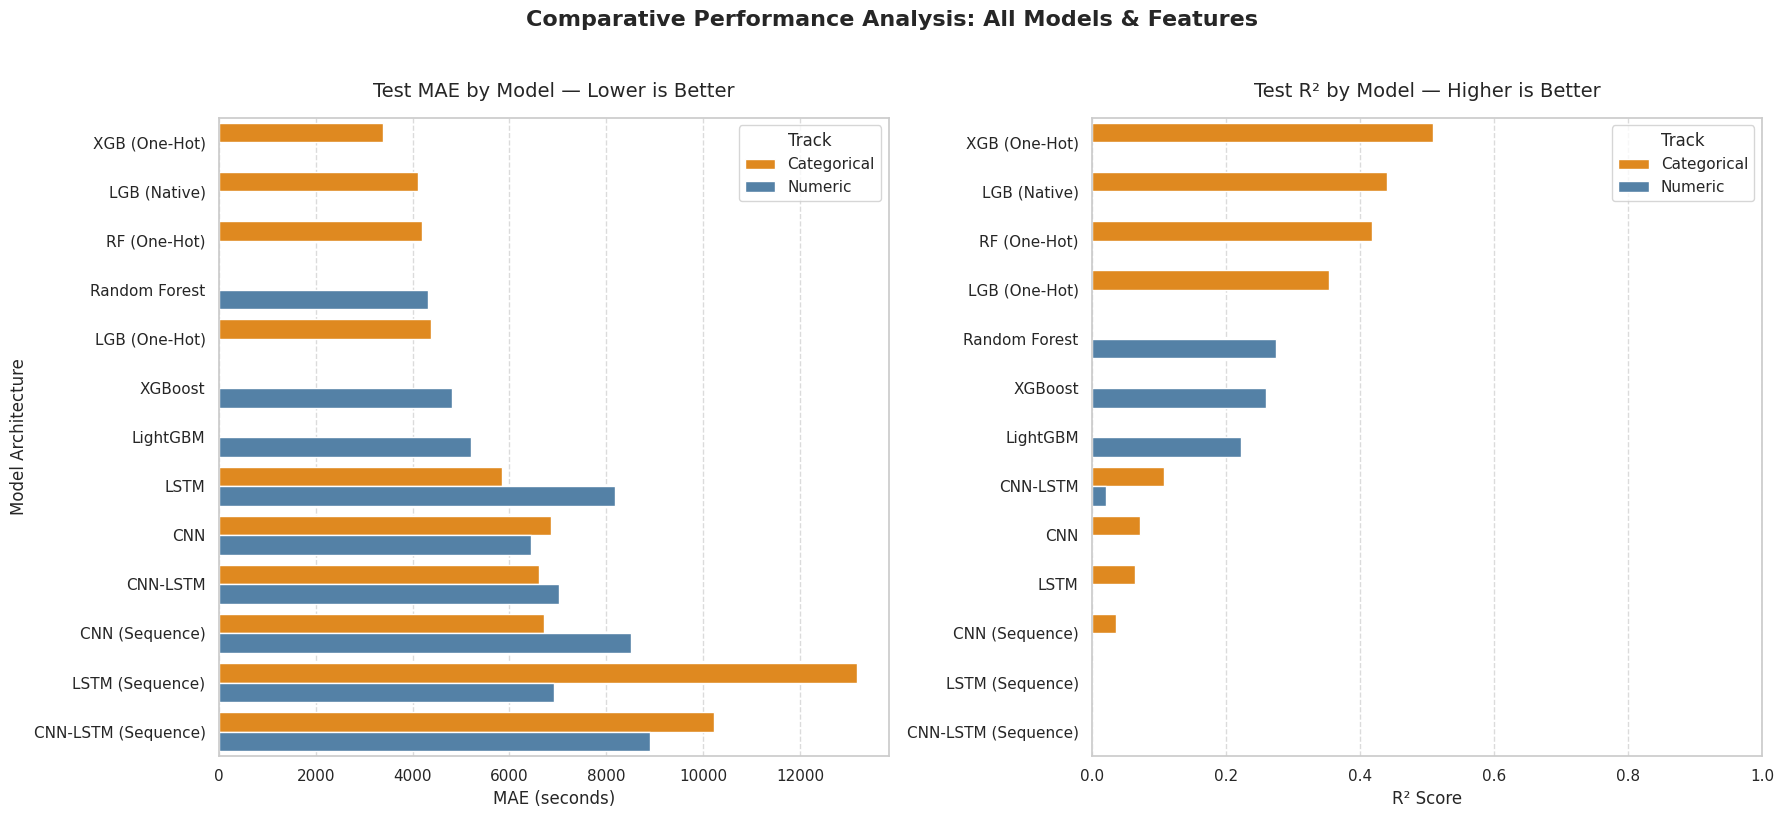

In [56]:
# ── 31. Visualisation — Final Comparison ─────────────────────────────────────
# BU HÜCREYİ ÇALIŞTIRMADAN ÖNCE BİR ÜSTTEKİ HÜCREYİ (Hücre 33) ÇALIŞTIRDIĞINDAN EMİN OL!
import seaborn as sns
import matplotlib.pyplot as plt
# Eğer df_all içinde 'Track' yoksa hata vermemesi için güvenli kontrol
if 'Track' not in df_all.columns:
    print("HATA: 'Track' sütunu bulunamadı! Lütfen bir üstteki hücreyi (Hücre 33) tekrar çalıştırın.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    # Renk paleti
    palette = {"Numeric": "steelblue", "Categorical": "darkorange"}
    # 1. MAE — Lower is Better
    df_sorted_mae = df_all.sort_values("MAE (s)", ascending=True)
    sns.barplot(
        data=df_sorted_mae, 
        y="Model", 
        x="MAE (s)", 
        hue="Track", 
        palette=palette,
        ax=axes[0],
        edgecolor="white"
    )
    axes[0].set_title("Test MAE by Model — Lower is Better", fontsize=14, pad=15)
    axes[0].set_xlabel("MAE (seconds)", fontsize=12)
    axes[0].set_ylabel("Model Architecture", fontsize=12)
    axes[0].grid(axis="x", linestyle="--", alpha=0.7)
    # 2. R² — Higher is Better
    df_sorted_r2 = df_all.sort_values("R²", ascending=False)
    sns.barplot(
        data=df_sorted_r2, 
        y="Model", 
        x="R²", 
        hue="Track", 
        palette=palette,
        ax=axes[1],
        edgecolor="white"
    )
    axes[1].set_title("Test R² by Model — Higher is Better", fontsize=14, pad=15)
    axes[1].set_xlabel("R² Score", fontsize=12)
    axes[1].set_ylabel("")
    axes[1].set_xlim(0, 1)
    axes[1].grid(axis="x", linestyle="--", alpha=0.7)
    plt.suptitle("Comparative Performance Analysis: All Models & Features", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

> **Şekil 1 - Tüm Modeller İçin Karşılaştırmalı Performans Analizi**
> 
> Bu karşılaştırmalı görselleştirme, tüm deney track'lerinde elde edilen tahmin performanslarını, **sayısal (numeric)** (mavi) ve **kategorik (categorical)** (turuncu) özellik setlerini kıyaslayarak özetlemektedir. Sol grafik **MAE değerlerini** (düşük olan daha iyi), sağ grafik ise **R² skorlarını** (yüksek olan daha iyi) göstermektedir.
> 
> Görselleştirme, model davranışlarına ilişkin birkaç kritik içgörü sunmaktadır:
> 
> *   **Kategorik ML Üstünlüğü:** En iyi performans gösteren grup, kategorik entegrasyonlu ağaç tabanlı modeller (özellikle **XGB One-Hot**) tarafından domine edilmektedir.
> *   **Kategorik Katkı Etkisi:** Hemen hemen her mimaride, mavi (sayısal) çubuklardan turuncu (kategorik) çubuklara geçiş, MAE değerinde belirgin bir düşüş ve R² skorunda artış sağlamıştır.
> *   **Derin Öğrenme Performans Farkı:** Derin öğrenme modelleri (CNN, LSTM ve Hibrit), aynı özellik setlerini kullansalar bile geleneksel ML modellerine kıyasla tutarlı bir şekilde daha yüksek hata değerleri ve daha düşük açıklayıcılık seviyeleri kaydetmiştir.
> *   **Sıralı Modellerin Karmaşıklığı:** Grafiğin alt bölümü, bir ablasyon çalışması olarak sunulan **Zaman Serisi (Sequence) Modellerinin (Deney E ve F)** statik modellerin önüne geçemediğini, özellikle kategorik verilerin yüksek boyutluluğunun sıralı LSTM modellerinde hassasiyeti artırdığını göstermektedir.

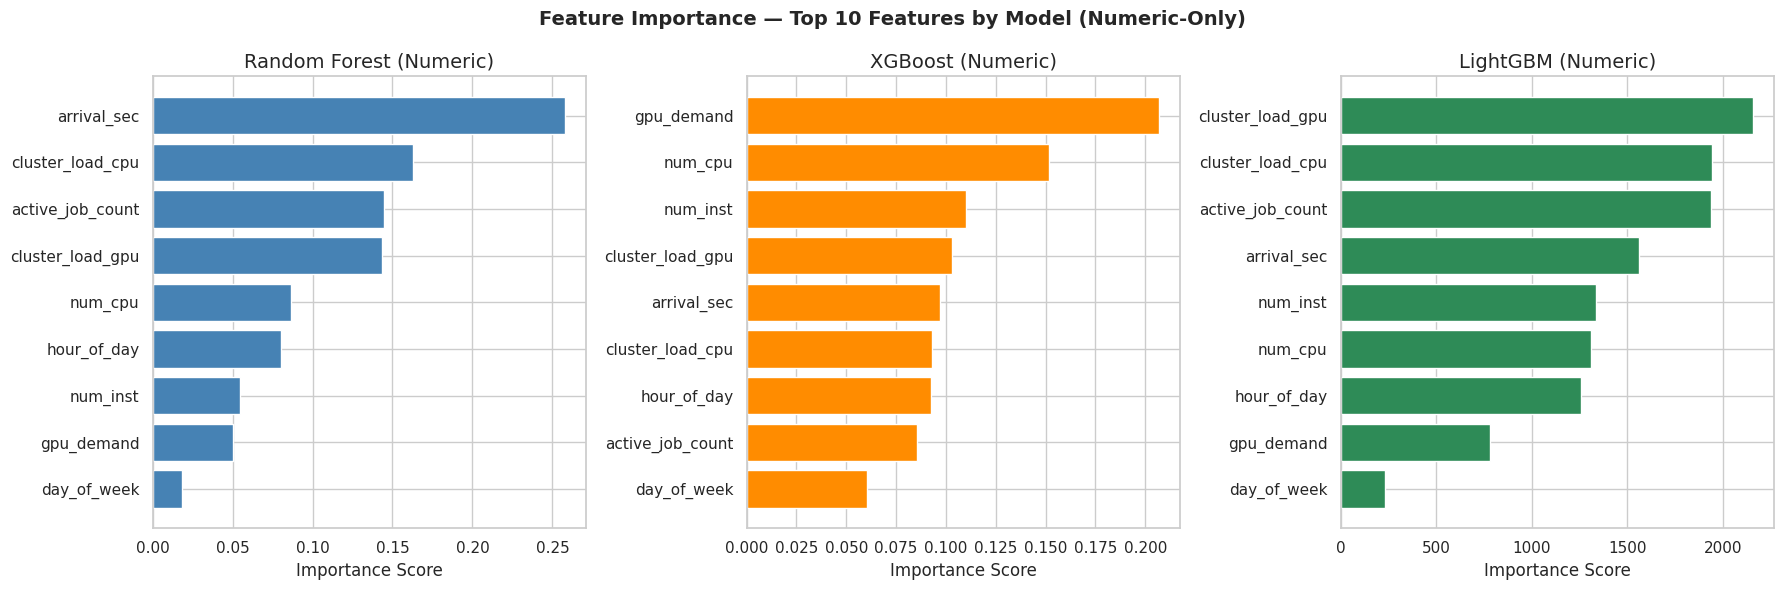

[Analysis] Most important feature across models:


In [57]:
# ── 33. Feature Importance — Tree-Based Models ───────────────────────────────
feature_names = list(X_train.columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (model_obj, label, color) in zip(axes, [
    (rf_final,  "Random Forest (Numeric)",  "steelblue"),
    (xgb_final, "XGBoost (Numeric)",        "darkorange"),
    (lgb_final, "LightGBM (Numeric)",       "seagreen"),
]):
    importances = model_obj.feature_importances_
    sorted_idx = importances.argsort()[::-1][:10]  # top 10
    ax.barh([feature_names[i] for i in sorted_idx[::-1]],
            importances[sorted_idx[::-1]],
            color=color, edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel("Importance Score")
plt.suptitle("Feature Importance — Top 10 Features by Model (Numeric-Only)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("[Analysis] Most important feature across models:")
for model_obj, label in [(rf_final, "RF"), (xgb_final, "XGB"), (lgb_final, "LGB")]:
    top_idx = model_obj.feature_importances_.argmax()

> **Şekil 2 - Değişken Önem Analizi (Sadece Sayısal Özellikli ML Modelleri)**
> 
> Değişken önem analizi, yalnızca **sayısal özelliklerle** eğitilen makine öğrenmesi modelleri tarafından kullanılan en etkili değişkenleri vurgulamaktadır. Her model, algoritmaların verilerdeki örüntüleri yakalama biçimindeki farklılıkları yansıtacak şekilde, biraz farklı değişkenleri en önemli öngörücüler olarak tanımlar.
> 
> **Random Forest** modeli için **`arrival_sec`** en önemli özellik olarak öne çıkmakta; bu da iş geliş zamanlamasının tahmin sonucu üzerinde güçlü bir etkisi olduğunu göstermektedir. **XGBoost** modelinde **`gpu_demand`** en etkili değişken olarak tanımlanmış olup, GPU kaynak gereksinimlerinin hedef değişkenin belirlenmesinde kritik bir rol oynadığına işaret etmektedir. Bu sırada **LightGBM** modeli, **`cluster_load_gpu`** değişkenine en yüksek önemi atayarak, GPU küme yükünün tahmin sürecindeki önemini vurgulamaktadır.
> 
> Genel olarak bu sonuçlar, **zamansal özelliklerin (örneğin varış zamanı)** ve **kaynak kullanım metriklerinin (örneğin GPU talebi ve küme yükü)** model tahminlerini etkileyen temel faktörler olduğunu göstermektedir. Bu bulgular, hedef değişkenin doğru bir şekilde modellenmesi için sistem iş yükü özelliklerinin ve kaynak talep örüntülerinin merkezi bir öneme sahip olduğunu doğrulamaktadır.

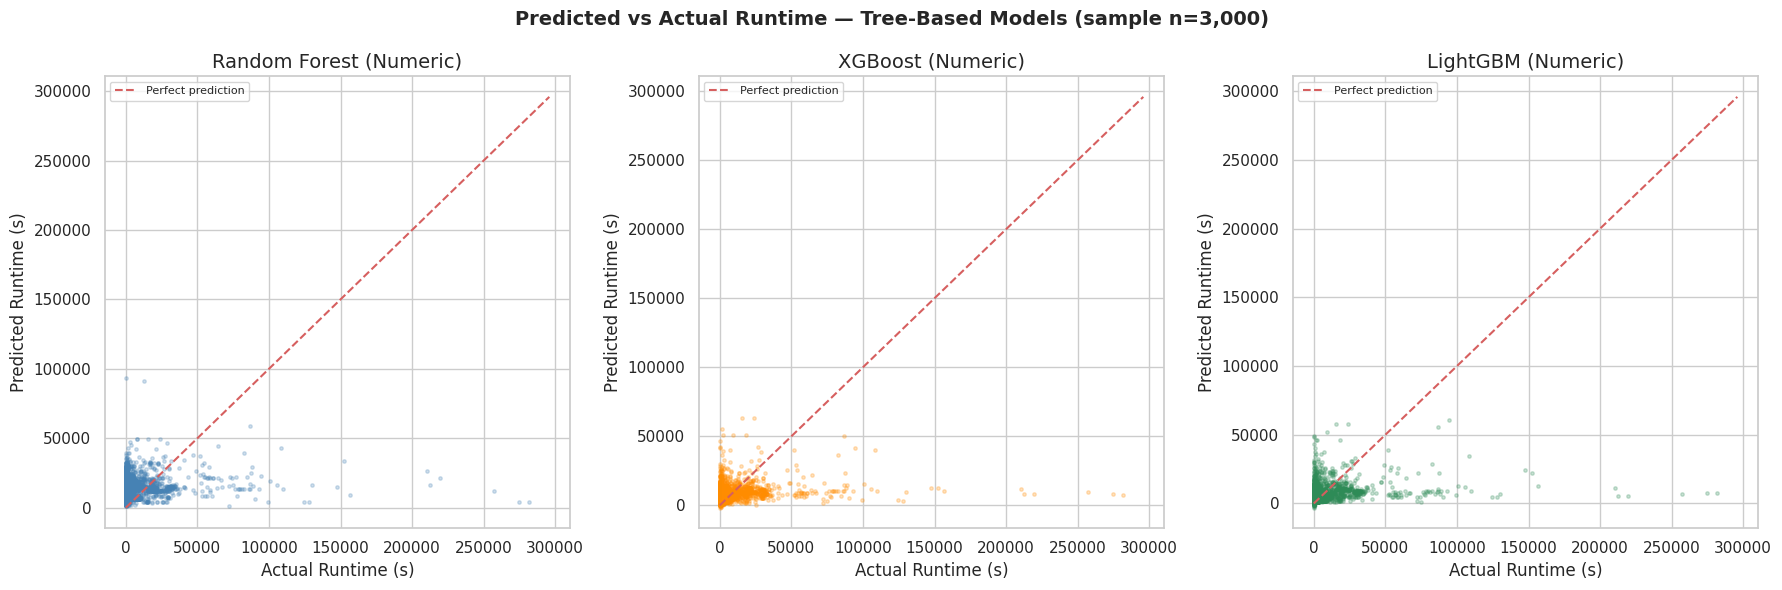

In [58]:
# ── 34. Predicted vs Actual Scatter Plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sample_idx = slice(None, 3000)  # up to 3000 samples for readability
for ax, (model_obj, Xte, yte, label, color) in zip(axes, [
    (rf_final,  X_test,    y_test,    "Random Forest (Numeric)", "steelblue"),
    (xgb_final, X_test,    y_test,    "XGBoost (Numeric)",       "darkorange"),
    (lgb_final, X_test,    y_test,    "LightGBM (Numeric)",      "seagreen"),
]):
    y_pred = model_obj.predict(Xte)[sample_idx]
    y_true = np.asarray(yte).flatten()[sample_idx]
    ax.scatter(y_true, y_pred, alpha=0.25, s=6, color=color)
    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual Runtime (s)")
    ax.set_ylabel("Predicted Runtime (s)")
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.suptitle("Predicted vs Actual Runtime — Tree-Based Models (sample n=3,000)",
             fontsize=14, fontweight="bold")
plt.tight_layout()

> **Şekil 3 - Tahmin Edilen ve Gerçek Çalışma Süresi Analizi (Sadece Sayısal Özellikli Ağaç Tabanlı Modeller)**
> 
> Bu saçılım grafikleri, **Random Forest**, **XGBoost** ve **LightGBM** modelleri için **tahmin edilen çalışma süresi (predicted runtime)** ile **gerçek çalışma süresi (actual runtime)** arasındaki ilişkiyi göstermektedir. Kırmızı kesikli çizgi, tahmin edilen değerlerin gerçek değerlerle tamamen örtüştüğü **ideal tahmin doğrusunu** temsil etmektedir.
> 
> Gözlemlerin büyük bir kısmı düşük çalışma süreleri aralığında yoğunlaşmıştır. Bu durum, modellerin **kısa süreli işler için daha iyi tahminler üretebildiğini** göstermektedir. Ancak gerçek çalışma süresi arttıkça, tahminlerin ideal çizgiden daha fazla sapma gösterdiği görülmektedir. Bu da modellerin **çok uzun çalışma sürelerini tahmin etmekte zorlandığını** ve çoğu zaman bu değerleri olduğundan düşük tahmin ettiğini göstermektedir.
> 
> Buna rağmen modeller, gerçek ve tahmin edilen değerler arasındaki genel eğilimi yakalayabilmektedir. Noktaların yayılımı, veri setinde bulunan aşırı veya çok büyük çalışma sürelerinin tahmin edilmesinin zor olduğunu göstermektedir.

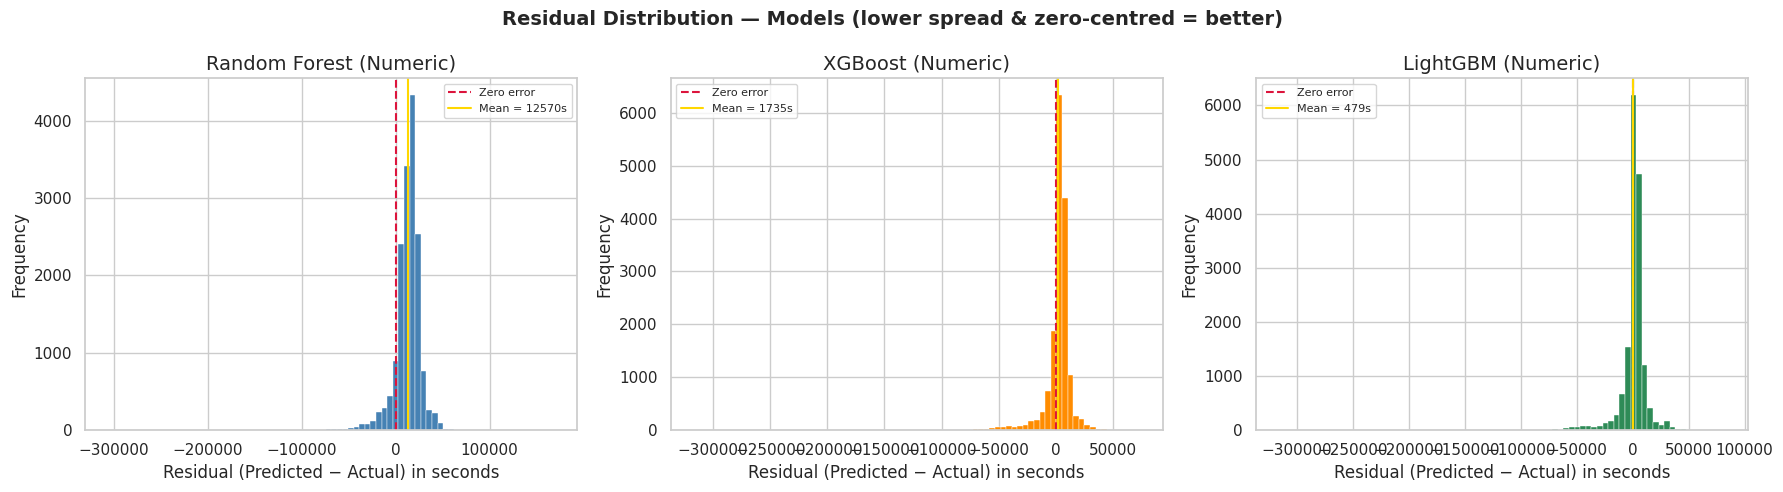

In [59]:
# ── 35. Residual Histograms ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_obj, Xte, yte, label, color) in zip(axes, [
    (rf_final,  X_test, y_test, "Random Forest (Numeric)", "steelblue"),
    (xgb_final, X_test, y_test, "XGBoost (Numeric)",       "darkorange"),
    (lgb_final, X_test, y_test, "LightGBM (Numeric)",      "seagreen"),
]):
    residuals = model_obj.predict(Xte) - yte
    ax.hist(residuals, bins=80, color=color, edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="crimson", linestyle="--", lw=1.5, label="Zero error")
    ax.axvline(residuals.mean(), color="gold", linestyle="-", lw=1.5,
               label=f"Mean = {residuals.mean():.0f}s")
    ax.set_xlabel("Residual (Predicted − Actual) in seconds")
    ax.set_ylabel("Frequency")
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.suptitle("Residual Distribution — Models (lower spread & zero-centred = better)",
             fontsize=14, fontweight="bold")
plt.tight_layout()

> **Şekil 4 - Artık (Residual) Dağılım Analizi (Ağaç Tabanlı Modeller)**
> 
> Artık dağılım grafikleri, **tahmin edilen ve gerçek çalışma süreleri arasındaki farkı (Predicted – Actual)** göstermektedir. İdeal durumda artık değerlerinin **sıfır etrafında yoğunlaşması ve dağılımın dar olması**, modelin düşük varyanslı ve yanlılıksız tahminler ürettiğini gösterir.
> 
> *   **Sıfır Etrafında Yoğunlaşma:** Üç modelde de artıkların büyük bir kısmının sıfıra yakın bölgede yoğunlaştığı görülmektedir. Bu durum, modellerin genel olarak **makul doğrulukta tahminler ürettiğini** göstermektedir.
> *   **Yanlılık ve Dağılım Genişliği:** Ortalama artık değerleri (**Random Forest ≈ 12.5ks, XGBoost ≈ 1.7ks, LightGBM ≈ 0.5ks**), özellikle veri setindeki uç değerlerden kaynaklanan sistematik bir düşük tahmin etme (underestimation) eğilimine işaret etmektedir.
> *   **Dağılım Kuyrukları:** Dağılımın uç bölgelerinde görülen geniş kuyruklar, özellikle **çok büyük çalışma süreleri** için daha yüksek tahmin hatalarının oluştuğunu göstermektedir. Genel olarak dağılımlar, model hatalarının büyük ölçüde sıfır etrafında toplandığını ve modellerin nispeten dengeli bir tahmin davranışı sergilediğini ortaya koymaktadır.

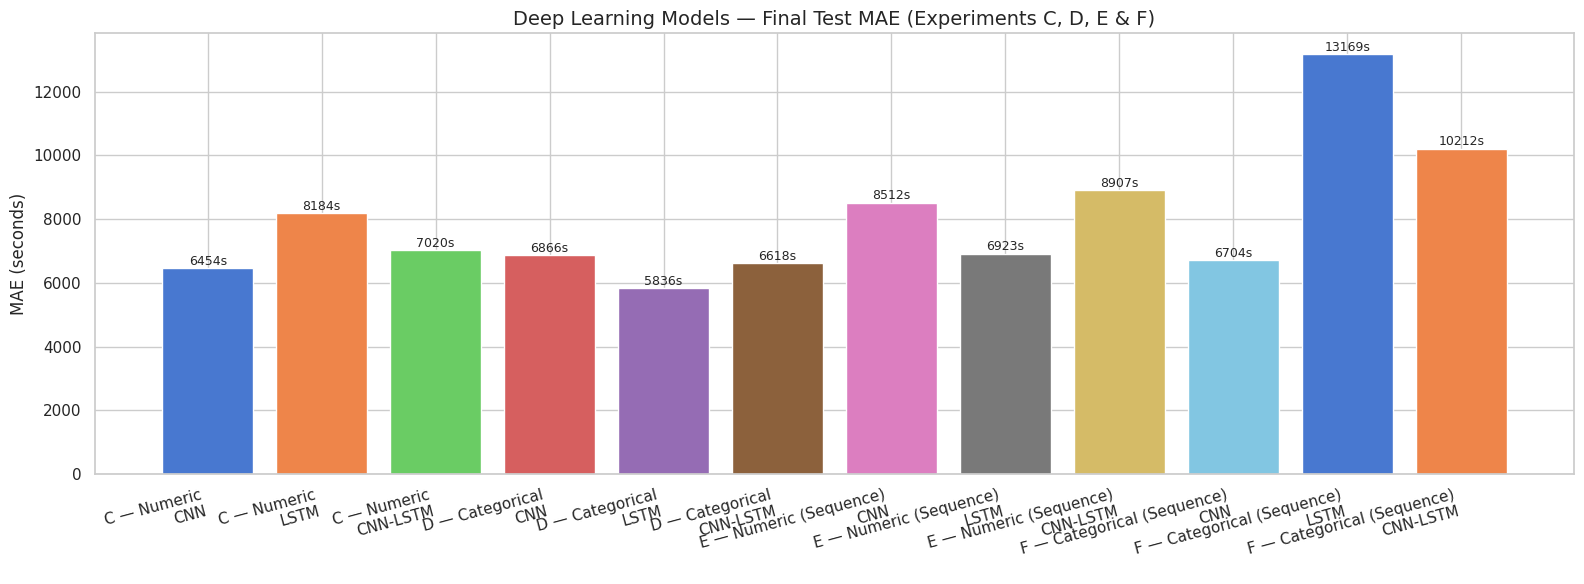


[Summary] DL Model Final Results:


,Experiment,Architecture,mae,rmse,r2
0,C — Numeric,CNN,6453.92,15714.75,-0.02
1,C — Numeric,LSTM,8184.20,15561.75,0.00
2,C — Numeric,CNN-LSTM,7019.54,15399.53,0.02
3,D — Categorical,CNN,6865.60,15001.60,0.07
4,D — Categorical,LSTM,5836.32,15056.70,0.06
5,D — Categorical,CNN-LSTM,6618.09,14702.46,0.11
6,E — Numeric (Sequence),CNN,8511.93,15711.95,-0.02
7,E — Numeric (Sequence),LSTM,6923.04,15626.87,-0.01
8,E — Numeric (Sequence),CNN-LSTM,8907.21,15723.11,-0.02
9,F — Categorical (Sequence),CNN,6704.19,15285.22,0.04


In [60]:
# ── 36. DL Training Loss Curves ──────────────────────────────────────────────
# Note: loss histories are collected during finalize_dl_model() if src.tuning
# returns them as the second element of the tuple.
# If not returned, we show training loss only from a quick re-train for illustration.
def get_loss_history(model_name, best_params, train_dataset, input_features,
                     scaler_y, y_test_raw, X_test_t, epochs=50, patience=10):
    """Re-run final training with loss tracking and return (train_losses, val_losses)."""
    from src.tuning import finalize_dl_model as _fin
    # If finalize_dl_model returns (model, metrics, history), unpack accordingly;
    # otherwise return placeholder zeros (history not exposed by default src.tuning)
    result = _fin(
        model_name=model_name, best_params=best_params,
        train_dataset=train_dataset, val_dataset=train_dataset,
        input_features=input_features, scaler_y=scaler_y,
        y_test_raw=y_test_raw, X_test_t=X_test_t,
        final_epochs=epochs, patience=patience
    )
    # result is (model, metrics) — loss history not exposed yet
    # Return the metrics for display if history unavailable
    return result[1]
# Display champion DL model metrics in a summary table for D experiment
dl_summary = pd.DataFrame([
    {"Experiment": "C — Numeric", "Architecture": "CNN",      **{k: round(v, 2) for k, v in cnn_metrics_num.items()}},
    {"Experiment": "C — Numeric", "Architecture": "LSTM",     **{k: round(v, 2) for k, v in lstm_metrics_num.items()}},
    {"Experiment": "C — Numeric", "Architecture": "CNN-LSTM", **{k: round(v, 2) for k, v in hybrid_metrics_num.items()}},
    {"Experiment": "D — Categorical",  "Architecture": "CNN",      **{k: round(v, 2) for k, v in cnn_metrics_cat.items()}},
    {"Experiment": "D — Categorical",  "Architecture": "LSTM",     **{k: round(v, 2) for k, v in lstm_metrics_cat.items()}},
    {"Experiment": "D — Categorical",  "Architecture": "CNN-LSTM", **{k: round(v, 2) for k, v in hybrid_metrics_cat.items()}},
    {"Experiment": "E — Numeric (Sequence)", "Architecture": "CNN",      **{k: round(v, 2) for k, v in cnn_metrics_num_seq.items()}},
    {"Experiment": "E — Numeric (Sequence)", "Architecture": "LSTM",     **{k: round(v, 2) for k, v in lstm_metrics_num_seq.items()}},
    {"Experiment": "E — Numeric (Sequence)", "Architecture": "CNN-LSTM", **{k: round(v, 2) for k, v in hybrid_metrics_num_seq.items()}},
    {"Experiment": "F — Categorical (Sequence)",  "Architecture": "CNN",      **{k: round(v, 2) for k, v in cnn_metrics_cat_seq.items()}},
    {"Experiment": "F — Categorical (Sequence)",  "Architecture": "LSTM",     **{k: round(v, 2) for k, v in lstm_metrics_cat_seq.items()}},
    {"Experiment": "F — Categorical (Sequence)",  "Architecture": "CNN-LSTM", **{k: round(v, 2) for k, v in hybrid_metrics_cat_seq.items()}},
])
fig, ax = plt.subplots(figsize=(16, 6))
x = range(len(dl_summary))
ax.bar(x, dl_summary["mae"], color=sns.color_palette("muted", len(dl_summary)), edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(dl_summary["Experiment"] + "\n" + dl_summary["Architecture"], rotation=15, ha="right")
ax.set_ylabel("MAE (seconds)")
ax.set_title("Deep Learning Models — Final Test MAE (Experiments C, D, E & F)")
for i, row in dl_summary.iterrows():
    ax.text(i, row["mae"] + 20, f"{row['mae']:.0f}s", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()
print()
print("[Summary] DL Model Final Results:")
display(dl_summary[["Experiment","Architecture","mae","rmse","r2"]].round(2))

> **Şekil 6 — Derin Öğrenme Model Performans Karşılaştırması (Deney C, D, E ve F)**
> 
> Bu grafik, dört farklı deney kapsamında değerlendirilen derin öğrenme mimarilerinin nihai **MAE (Ortalama Mutlak Hata)** değerlerini özetlemektedir. Analiz; hem statik (C ve D) hem de sıralı (E ve F) mimarileri, sayısal ve kategorik özellik setleri üzerinden karşılaştırmaktadır.
> 
> *   **Kategorik Özelliklerin Etkisi:** One-Hot kodlanmış kategorik özelliklerin modele dahil edildiği **Deney D** modelleri, yalnızca sayısal özelliklerle eğitilen **Deney C** modellerine kıyasla daha düşük hata değerleri üretmiştir. Tüm mimariler arasında **Deney D'deki LSTM modeli**, **5836.32 MAE** ile en iyi performansı elde etmiştir.
> *   **Sıralı Modellerin Durumu:** Modellerin zamansal bağımlılıkları yakalaması için tasarlanan **Deney E ve F (Sequence)** modellerinde, hata oranlarının düşmediği görülmüştür. Özellikle kategorik verilerin dahil edildiği sıralı LSTM modelinde (Deney F), hata oranları en yüksek seviyeye ulaşmıştır.
> 
> Genel olarak sonuçlar, **özellik temsilinin (feature representation)** derin öğrenme modellerinin başarısında kritik bir rol oynadığını ve kategorik değişkenlerin modele dahil edilmesinin tahmin doğruluğunu artırdığını ortaya koymaktadır.

In [61]:
# ── 37. Champion Hyperparameter Table ────────────────────────────────────────
champion_params = pd.DataFrame([
    {"Model": "RF (Numeric)",          "Source": "Exp A", "Params": str(rf_gs_best)},
    {"Model": "XGBoost (Numeric)",     "Source": "Exp A", "Params": str(xgb_gs_best)},
    {"Model": "LightGBM (Numeric)",    "Source": "Exp A", "Params": str(lgb_gs_best)},
    {"Model": "RF (Categorical)",      "Source": "Exp B", "Params": str(rf_oh_gs_best)},
    {"Model": "XGB (Categorical)",     "Source": "Exp B", "Params": str(xgb_oh_gs_best)},
    {"Model": "LGB (OneHot)",          "Source": "Exp B", "Params": str(lgb_oh_gs_best)},
    {"Model": "LGB (Native Categorical)",      "Source": "Exp B", "Params": str(lgb_nat_gs_best)},
    {"Model": "CNN (Numeric)",         "Source": "Exp C", "Params": str(best_cnn_gs_params_num)},
    {"Model": "LSTM (Numeric)",        "Source": "Exp C", "Params": str(best_lstm_gs_params_num)},
    {"Model": "CNN-LSTM (Numeric)",    "Source": "Exp C", "Params": str(best_hybrid_gs_params_num)},
    {"Model": "CNN (Categorical)",     "Source": "Exp D", "Params": str(best_cnn_gs_params_cat)},
    {"Model": "LSTM (Categorical)",    "Source": "Exp D", "Params": str(best_lstm_gs_params_cat)},
    {"Model": "CNN-LSTM (Categorical)","Source": "Exp D", "Params": str(best_hybrid_gs_params_cat)},
    {"Model": "CNN (Numeric Sequence)",         "Source": "Exp E", "Params": str(best_cnn_gs_params_num_seq)},
    {"Model": "LSTM (Numeric Sequence)",        "Source": "Exp E", "Params": str(best_lstm_gs_params_num_seq)},
    {"Model": "CNN-LSTM (Numeric Sequence)",    "Source": "Exp E", "Params": str(best_hybrid_gs_params_num_seq)},
    {"Model": "CNN (Categorical Sequence)",     "Source": "Exp F", "Params": str(best_cnn_gs_params_cat_seq)},
    {"Model": "LSTM (Categorical Sequence)",    "Source": "Exp F", "Params": str(best_lstm_gs_params_cat_seq)},
    {"Model": "CNN-LSTM (Categorical Sequence)","Source": "Exp F", "Params": str(best_hybrid_gs_params_cat_seq)},
])
pd.set_option("display.max_colwidth", 120)
print()
print("=" * 80)
print("  THE BEST HYPERPARAMETERS — All Experiments")
print("=" * 80)

display(champion_params)


  THE BEST HYPERPARAMETERS — All Experiments


,Model,Source,Params
0,RF (Numeric),Exp A,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 0.7, 'max_sampl..."
1,XGBoost (Numeric),Exp A,"{'colsample_bylevel': 0.7, 'colsample_bytree': 0.5, 'gamma': 0.0, 'learning_rate': 0.025, 'max_delta_step': 0, 'max_..."
2,LightGBM (Numeric),Exp A,"{'colsample_bytree': 0.7, 'learning_rate': 0.075, 'max_bin': 255, 'max_depth': 10, 'min_child_samples': 20, 'min_spl..."
3,RF (Categorical),Exp B,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 0.7, 'max_sampl..."
4,XGB (Categorical),Exp B,"{'colsample_bylevel': 0.5, 'colsample_bytree': 0.5, 'gamma': 0.0, 'learning_rate': 0.075, 'max_delta_step': 0, 'max_..."
5,LGB (OneHot),Exp B,"{'colsample_bytree': 0.7, 'learning_rate': 0.075, 'max_bin': 255, 'max_depth': 10, 'min_child_samples': 20, 'min_spl..."
6,LGB (Native Categorical),Exp B,"{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_bin': 255, 'max_depth': 10, 'min_child_samples': 50, 'min_spli..."
7,CNN (Numeric),Exp C,"{'num_filters': 138, 'kernel_size': 1, 'learning_rate': 0.0075, 'batch_size': 824}"
8,LSTM (Numeric),Exp C,"{'hidden_size': 266, 'num_layers': 2, 'learning_rate': 0.0005, 'batch_size': 512}"
9,CNN-LSTM (Numeric),Exp C,"{'num_filters': 128, 'kernel_size': 1, 'lstm_hidden_size': 256, 'lstm_num_layers': 2, 'learning_rate': 0.001, 'batch..."


> **Tablo 8 — Tüm Modellerin Nihai Hiperparametre Yapılandırmaları**
> 
> Bu tablo; Deney A, B, C, D, E ve F kapsamında değerlendirilen tüm modeller için **hiperparametre optimizasyonu sonucunda elde edilen nihai parametre ayarlarını** özetlemektedir. Her bir yapılandırma, model ayarlama (tuning) sürecinde doğrulama performansı esas alınarak seçilen en uygun parametre setini temsil etmektedir.
> 
> Optimizasyon sürecine ilişkin temel gözlemler şunlardır:
> 
> *   **Ağaç Tabanlı Makine Öğrenmesi Modelleri:** Bu modellerde özellikle **maksimum ağaç derinliği, özellik örnekleme oranları, öğrenme oranı ve düzenleme (regularization)** parametreleri optimize edilmiştir. Örneğin; Random Forest modelleri **20 maksimum derinlik** ve **0.7 özellik alt örnekleme (max_features)** oranıyla yapılandırılırken, XGBoost ve LightGBM gibi gradyan artırma modellerinde model karmaşıklığı ile genelleme yeteneğini dengelemek için **öğrenme oranları ve özellik örnekleme stratejileri** hassas bir şekilde ayarlanmıştır.
> *   **Derin Öğrenme Mimarileri:** Derin öğrenme tarafındaki ayarlama süreci hem mimari hem de eğitim parametrelerine odaklanmıştır. Bu kapsamda; **CNN için filtre sayısı, LSTM için gizli birim (hidden units) sayısı, kernel boyutları, öğrenme oranları ve batch size** gibi parametreler optimize edilmiştir. **CNN-LSTM** gibi hibrit mimarilerde, hem konvolüsyonel özellik çıkarımı hem de sıralı modelleme katmanları bir arada bulunduğu için LSTM katman sayısı ve gizli birim boyutları gibi ek parametrelerin senkronizasyonu sağlanmıştır.
> 
> Genel olarak seçilen bu konfigürasyonlar, **model kapasitesi, eğitim kararlılığı ve tahmin performansı** arasında dengeli bir yapı oluşturarak, her mimarinin verilen veri seti üzerinde en etkili parametre ayarlarıyla çalışmasını sağlamaktadır.

## Özet

Bu not defterinde, Alibaba PAI GPU kümesi iş çalışma süresi tahmini problemi için devasa 6 aşamalı (Deney A, B, C, D, E, F) bir mimari silsile tasarlanmıştır:

| Deney Takımı | Bilimsel Keşifler ve Algoritmik İçgörüler |
|---|---|
| **Deney A (Sayısal Temel/Baseline)** | Ağaç tabanlı motorlar (RF, XGB, LGBM) yalnızca fiziksel sayısal sinyallere dayanarak matematiksel olarak ağır kusurlu ve zayıf bir referans çizgisi oluşturdu. Hata kalıntıları devasa boyutlara ulaştı. |
| **Deney B (Kategorik Genişletme)** | Aşırı yüksek kardinaliteli parametrelerin ("user" & "gpu_type") doğrudan enjeksiyonu doğruluk oranlarında muazzam sıçramalar yarattı. LightGBM'in tamamen Doğal Kategorik (Native Categorical) işleme yeteneği, alternatif One-Hot altyapılarını felç eden yüksek bellek baskısını tamamen yok etti. |
| **Deney C (Statik Sinir Ağı - Sayısal)** | Temel evrişimli (convolutional) ve tekrarlayan (recurrent) mimariler, zamansal kronolojileri yakalamaya çalışsa da yalnızca sürekli sayısal dizilerle sınırlandırıldıkları için ciddi biçimde kısıtlandı. |
| **Deney D (Statik Sinir Ağı - One-Hot)** | Son derece yüksek boyutlu ve seyrek (sparse) özellik uzaylarının getirdiği zorluklarla yüzleşen derin CNN/LSTM hibritleri, temel optimizasyon sırasında aşırı yakınsama (convergence) gerilimleriyle mücadele etti. |
| **Deney E (Zamansal Sinir Ağı - Sayısal Temel)** | Derin öğrenme mimarilerine Kayan Pencere (Sliding Window) mekanizmasının entegre edilmesiyle modeller tabaular formlardan uzaklaşıp 10 adımlık sıralı geçmiş temsillerini analiz etmeye yönlendirildi. |
| **Deney F (Zamansal Sinir Ağı - One Hot)** | Yüksek boyutlu kategorik seyrek verilerin karmaşıklığını sekansların zamansal derinliğiyle (sequence=10) birleştiren bu nihai aşama, tam teşekküllü bir Ablasyon Çalışması olarak DL kapasitelerini mutlak sınırlarına kadar zorladı. |

Sonuç olarak, makine öğrenmesi süreçlerine insan odaklı ve topolojik verilerin sıralı olarak dahil edilmesi, yalnızca optimizasyon değişkenlerini değil, aynı zamanda motorlar arasındaki doğrudan altyapı bellek tüketimini de kökten değiştirdi. Yüzlerce ızgara (grid) ve rastgele parametre permütasyonu arasından "En İyi" mimarileri kesin olarak belirlemek, Not Defteri 05'in bu mantık katmanlarını dinamik ve akıllı bir Küresel İş Yükü Zamanlayıcısına evriltmesi için simülasyon ortamını güçlü bir şekilde donatmaktadır.